# **TD Détection des bosons de Higgs**

Le boson de Higgs est une particule élémentaire fondamentale, prédite dans les années 1960 et découverte en 2012 au CERN (Conseil européen pour la recherche nucléaire) aujourd'hui appelé l'organisation européenne pour la recherche nucléaire.

Il s'agit de la manifestation quantique du champ de Higgs, un champ invisible qui remplit tout l’Univers et qui joue un rôle essentiel : **il permet à certaines particules d’acquérir une masse.**

Sans le champ de Higgs, toutes les particules iraient à la vitesse de la lumière. Elles ne pourraient donc pas se lier, pas se stabiliser, pas interagir durablement. Ainsi, les atomes, la chimie, les étoiles, les planètes, la vie, rien ne pourrait exister.


Détecter cette particule est essentiel car sa mise en évidence expérimentale permet de confirmer une pièce fondamentale du modèle standard et de mieux comprendre la structure et l’évolution de l’Univers.

Cependant, cette detection est difficile. En partticulier pour trois raisons principales :
- **sa rareté** : Le boson de Higgs est produit dans des conditions très spécifiques. Il faut concentrer une énergie colossale dans un point minuscule.
- **sa durée de vie extrêmement courte** : C’est l’une des particules les plus instables du modèle standard. Sa durée de vie : environ 10⁻²² secondes.
- et **le bruit énorme dans lequel il apparaît** : Les particules issues de sa désintégration ne sont pas uniques et sont produites aussi par beaucoup d’autres processus sans Higgs.


Il faut donc employer des statistiques massives, des modèles très précis et des algorithmes de reconstruction complexes pour pouvoir **voir** le Higgs.
Et dans le cas de ce projet, l'approche que nous allons utiliser pour la détection du Boson de Higgs est le machine learning.

## I - Préparation des données (Pre-processing)

### 1- Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import csv
import time
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn import model_selection
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### 2- Lecture des fichiers CSV
Le jeu de données utilisé dans le cadre de cet exercice est disponible dans http://opendata.cern.ch/record/328

In [2]:
dataFilename = 'data/atlas-higgs-challenge-2014-v2.csv'
data = pd.read_csv(dataFilename)

Le dataset provient de la simulation officielle ATLAS (CERN), obtenue grace au grand collisionneur de hadrons (LHC) l'accélérateur de particules le plus grand et le plus puissant du monde, par reproduction les collisions proton–proton, simulées selon les connaissances de la physique des particules et le passage des particules dans un modèle virtuel du détecteur, qui permet de générer des événements réalistes.


Ces simulations imitent fidèlement les propriétés statistiques des collisions réelles, tout en fournissant des informations internes non observables en conditions expérimentales.


In [3]:
print(data.shape)
data.head()

(818238, 35)


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333


Nous travaillons sur un jeu de données de 818 238 évenements (observations)  décrites par 35 conditions d'expérimentation (caratéristiques).

In [4]:
print(data.dtypes)

EventId                          int64
DER_mass_MMC                   float64
DER_mass_transverse_met_lep    float64
DER_mass_vis                   float64
DER_pt_h                       float64
DER_deltaeta_jet_jet           float64
DER_mass_jet_jet               float64
DER_prodeta_jet_jet            float64
DER_deltar_tau_lep             float64
DER_pt_tot                     float64
DER_sum_pt                     float64
DER_pt_ratio_lep_tau           float64
DER_met_phi_centrality         float64
DER_lep_eta_centrality         float64
PRI_tau_pt                     float64
PRI_tau_eta                    float64
PRI_tau_phi                    float64
PRI_lep_pt                     float64
PRI_lep_eta                    float64
PRI_lep_phi                    float64
PRI_met                        float64
PRI_met_phi                    float64
PRI_met_sumet                  float64
PRI_jet_num                      int64
PRI_jet_leading_pt             float64
PRI_jet_leading_eta      

Une rapide analyse du jeu de donnée correspondant à la lecture de ses premieres lignes ainsi que de la documentation et du type de ses caractéristiques nous suggère des rapides modifications sur les données. 


D'une part, notre variable cible est la variable **`Label`** qui décrit le but de notre exercice.\
Elle décrit si un événement correspond à un **signal (s)** : un événement issu d’un processus rare contenant potentiellement un boson de Higgs ou à un **bruit de fond (b)** : un événement dû à un autre processus physique Standard Model courant, qui imite la signature du Higgs sans en contenir.
Elle est encodée sous la forme **s/b** ce qui n'est pas compréhensible pour nos modeles.


D'autre part, chaque événement simulé possède un poids lié à **la méthode d’importance sampling du simulateur**.\
Il permet de corriger la densité artificielle générée par la simulation mais ne doivent pas être utilisés comme features d’entrée selon la doumenation du dataset.


La prochaine étape est d'appliquer les corrections suivantes: supprimer les colonnes superflues et transformer la colonne 'Label' en valeurs binaires 0/1.

### 3- Supprimer les colonnes superflues


In [5]:
# Suppression des colonnes
cols_to_drop = ['EventId', 'Weight', 'KaggleSet', 'KaggleWeight']
for col in cols_to_drop: 
   del data[col]

In [6]:
# Transformation de la colonne Label en binaire 0/1
## s->1
## b->0
data['Label'] = data['Label'].astype('category')
data['Label'] = data['Label'].cat.codes.astype('category')  

print(data['Label'].dtype)

data['Label'].head(5)

category


0    1
1    0
2    0
3    0
4    0
Name: Label, dtype: category
Categories (2, int8): [0, 1]

### 4- Traiter les données manquantes

Les données manquantes dans ce fichier sont codées  par -999 il faut donc les traiter comme des valeurs à imputer.\
Pour les remplacer, il utilisera la classe `SimpleImputer (dans sklearn.impute)`.

Il est question d'un outil qui permet de remplacer automatiquement les valeurs manquantes dans un jeu de données par une valeur calculée selon une stratégie définie :\
	•	moyenne (mean)\
	•	médiane (median)\
	•	valeur la plus fréquente (most_frequent)\
	•	constante définie par l’utilisateur (constant)


In [7]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=-999, strategy='mean')
data_imputed = imputer.fit_transform(data)
data = pd.DataFrame(data_imputed, columns=data.columns)
data['Label'] = data['Label'].astype(int).astype('category')

Ici, je demande à `SimpleImputer` de remplacer les valeurs manquantes encodées par -999 par la moyenne de chaque colonne.

##### Vérification

In [8]:
(data == -999).sum()

DER_mass_MMC                   0
DER_mass_transverse_met_lep    0
DER_mass_vis                   0
DER_pt_h                       0
DER_deltaeta_jet_jet           0
DER_mass_jet_jet               0
DER_prodeta_jet_jet            0
DER_deltar_tau_lep             0
DER_pt_tot                     0
DER_sum_pt                     0
DER_pt_ratio_lep_tau           0
DER_met_phi_centrality         0
DER_lep_eta_centrality         0
PRI_tau_pt                     0
PRI_tau_eta                    0
PRI_tau_phi                    0
PRI_lep_pt                     0
PRI_lep_eta                    0
PRI_lep_phi                    0
PRI_met                        0
PRI_met_phi                    0
PRI_met_sumet                  0
PRI_jet_num                    0
PRI_jet_leading_pt             0
PRI_jet_leading_eta            0
PRI_jet_leading_phi            0
PRI_jet_subleading_pt          0
PRI_jet_subleading_eta         0
PRI_jet_subleading_phi         0
PRI_jet_all_pt                 0
Label     

### 5- Gestion des données aberrantes

#### Détection

D'une part je vérifie si le jeu de données contient des données abérrantes en affichant les boxplot de toutes les colonnes.

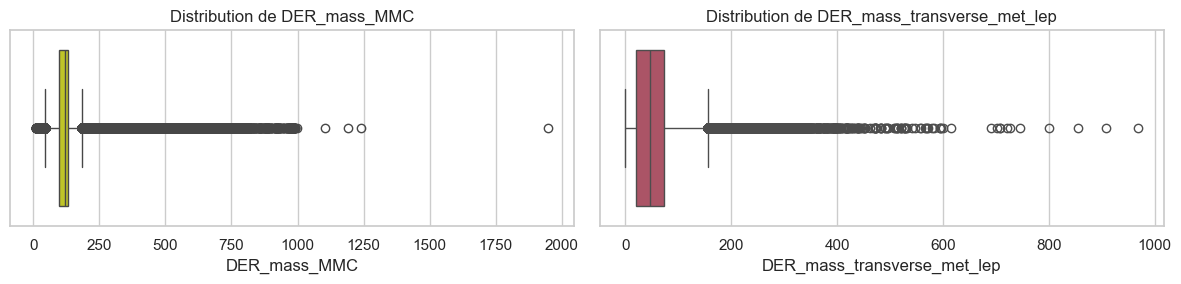

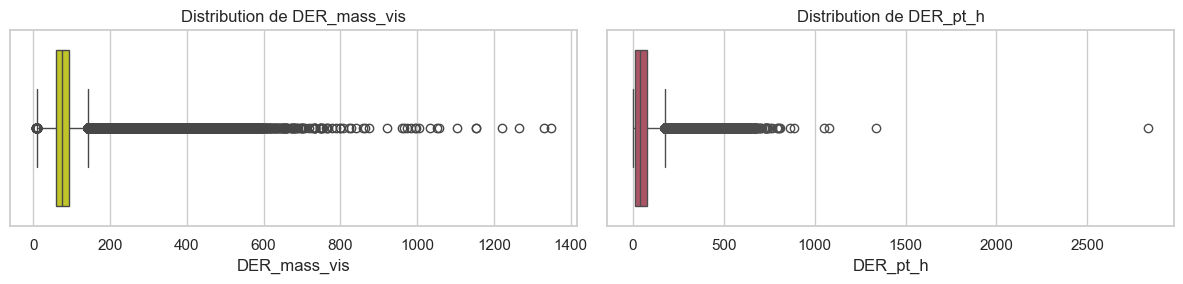

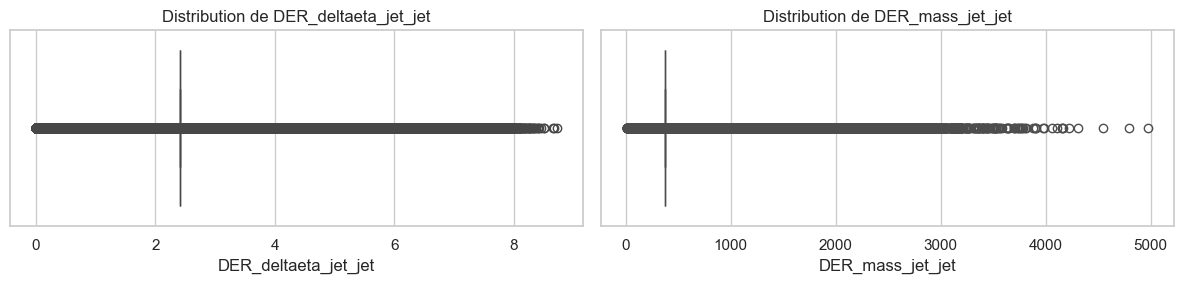

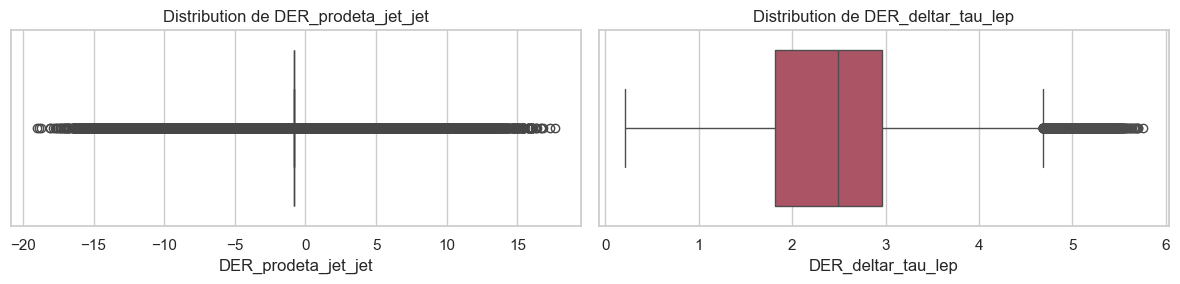

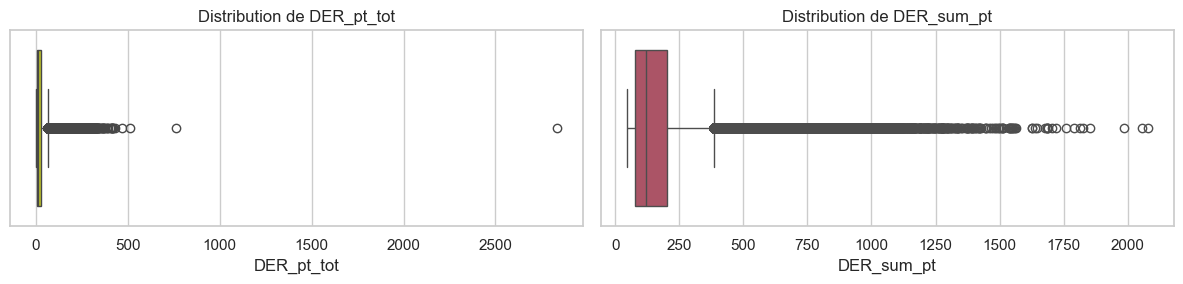

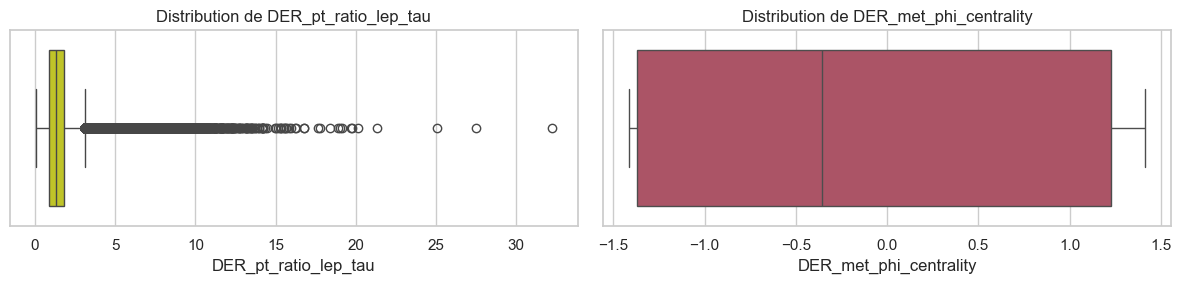

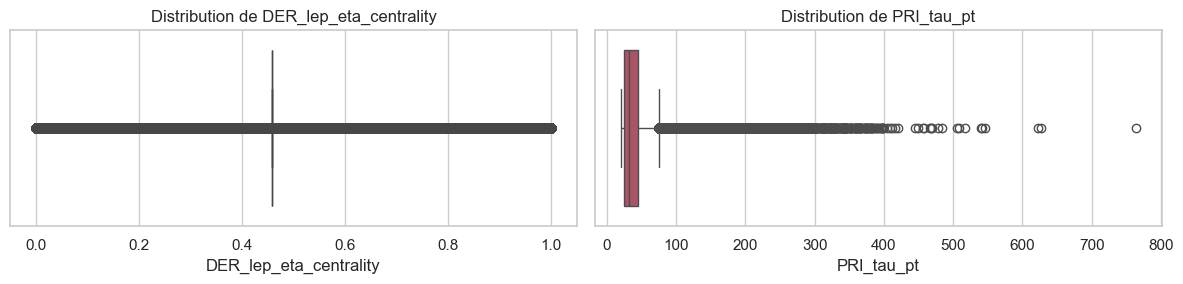

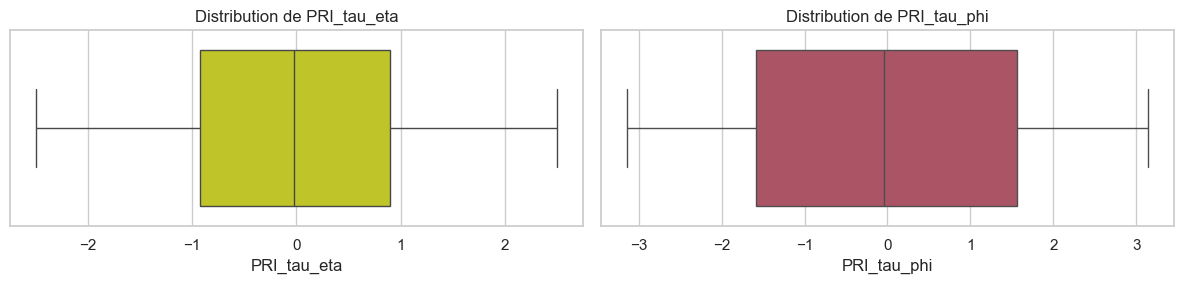

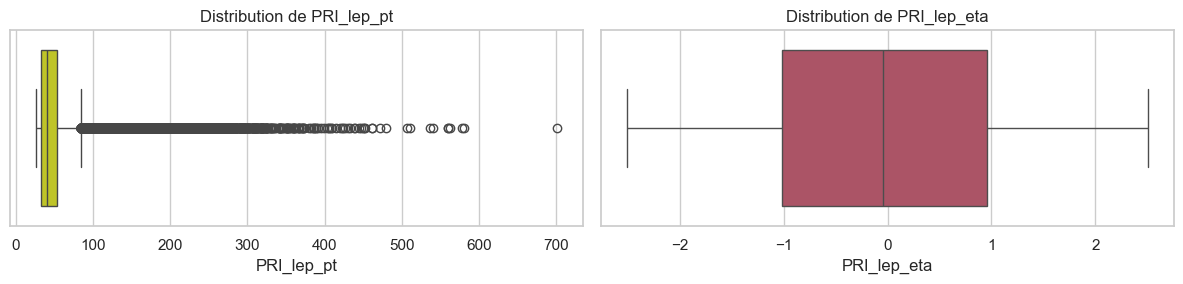

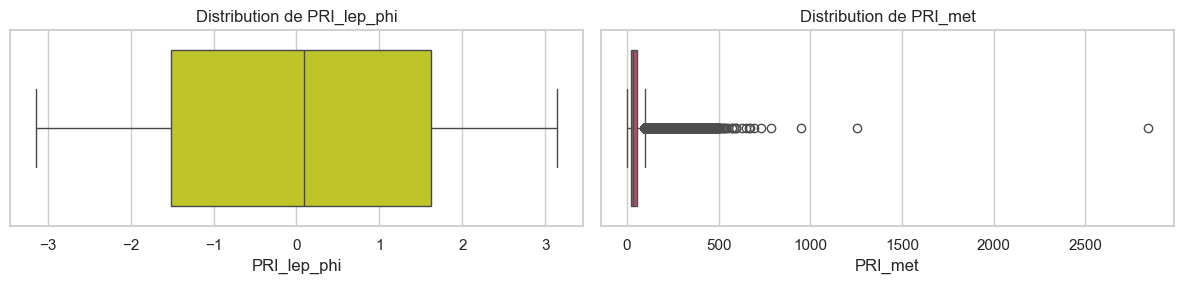

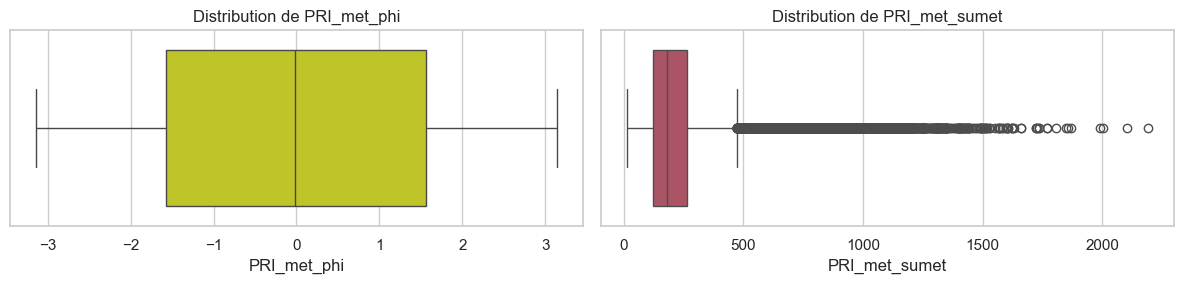

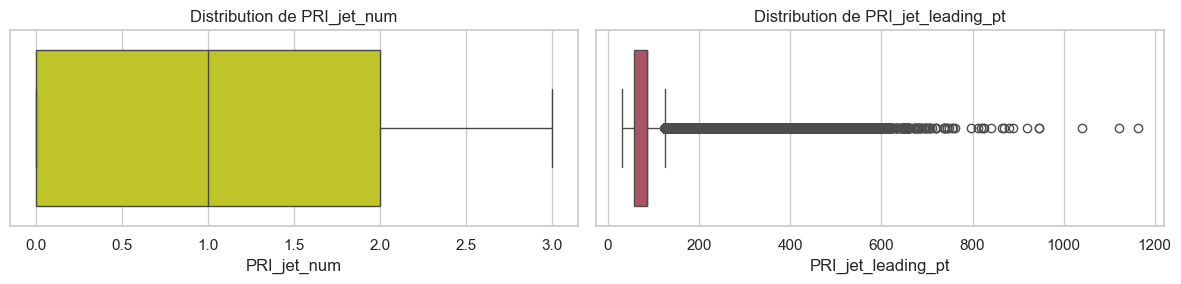

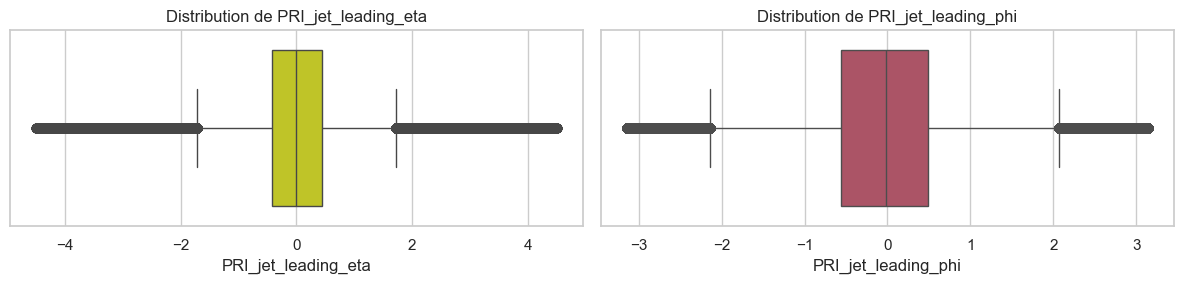

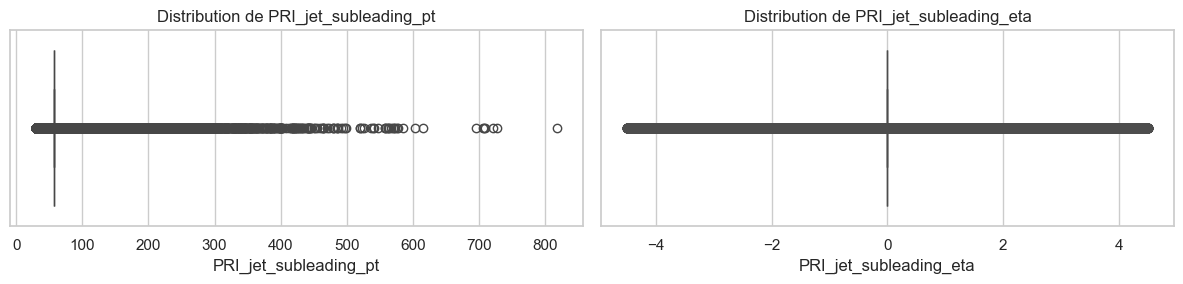

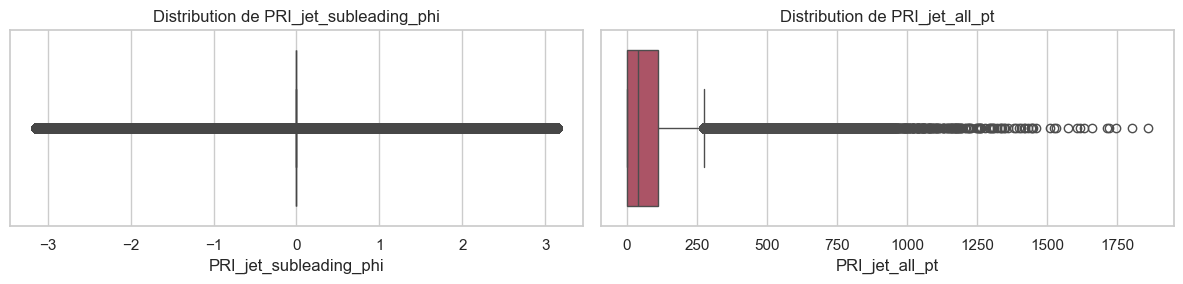

In [9]:
sns.set_theme(style="whitegrid", palette="crest")

num_cols = data.select_dtypes(include=['float64', 'int64']).columns

for i in range(0, len(num_cols), 2):
    col1 = num_cols[i]
    col2 = num_cols[i+1] if i+1 < len(num_cols) else None

    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharex=False)
    
    sns.boxplot(x=data[col1], ax=axes[0], color="#D7DE0E48")
    axes[0].set_title(f"Distribution de {col1}")

    if col2 is not None:
        sns.boxplot(x=data[col2], ax=axes[1], color="#BA455D")
        axes[1].set_title(f"Distribution de {col2}")
    else:
        axes[1].axis("off")

    fig.tight_layout()
    plt.show()


#### Traitement


Dans le cadre de la détection du boson de Higgs, il n’est pas pertinent de supprimer ou de corriger les valeurs aberrantes, car celles-ci peuvent correspondre à des événements physiques rares mais authentiques, caractéristiques du signal que l’on cherche précisément à identifier.

Les collisions du LHC produisent naturellement des mesures extrêmes, liées soit à des fluctuations statistiques importantes, soit à des processus énergétiques inhabituels, et les éliminer pourrait conduire à écarter des observations réellement compatibles avec un événement de type Higgs.


Par ailleurs, la frontière entre un “outlier” expérimental et un signal précieux est souvent difficile à établir dans un environnement aussi bruité et multidimensionnel. 

Pour cette raison, il est préférable d’utiliser des modèles de machine learning robustes à la présence de valeurs extrêmes, capables d’intégrer l’ensemble des observations sans être perturbés par quelques mesures atypiques, et de laisser les algorithmes exploiter ces variations pour améliorer la détection du boson de Higgs.

### 6-  Calibration des données avec *MinMaxScaler* de Sci-kit Learn

Les différentes données étant dans des unités de mesure différente, nous devons mettre à l'échelle toutes les colonnes.

Pour cela on utilise `MinMaxScaler`, une méthode de normalisation proposée par scikit-learn qui permet de transformer les variables numériques pour qu’elles soient ramenées dans une échelle fixe, généralement entre 0 et 1.

In [10]:
from sklearn.preprocessing import MinMaxScaler

X=data[num_cols]
scaler = MinMaxScaler()

X_scaled=scaler.fit_transform(X)
X=pd.DataFrame(X_scaled, columns=X.columns)
X.head(20)

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,0.066707,0.053326,0.068128,0.009869,0.104310,0.022395,0.591293,0.515244,0.014789,0.074595,...,0.455920,0.112586,0.666667,0.033028,0.738889,0.570656,0.020388,0.637778,0.106143,0.061014
1,0.078287,0.070992,0.072155,0.016983,0.275633,0.072274,0.495970,0.589031,0.000733,0.038884,...,0.195099,0.069314,0.333333,0.014316,0.580556,0.684278,0.035301,0.499259,0.498334,0.024850
2,0.058150,0.167417,0.089071,0.012570,0.275633,0.072274,0.495970,0.530399,0.003293,0.074622,...,0.152132,0.113359,0.333333,0.012573,0.728111,0.177276,0.035301,0.499259,0.498334,0.023789
3,0.069508,0.084050,0.055557,0.000146,0.275633,0.072274,0.495970,0.559625,0.000146,0.014690,...,0.509548,0.033256,0.000000,0.048440,0.499861,0.496999,0.035301,0.499259,0.498334,0.000000
4,0.085980,0.017462,0.095662,0.005787,0.275633,0.072274,0.495970,0.664442,0.005787,0.005843,...,0.361394,0.018126,0.000000,0.048440,0.499861,0.496999,0.035301,0.499259,0.498334,0.000000
5,0.041593,0.013988,0.039329,0.041038,0.302155,0.054618,0.503846,0.208191,0.021735,0.114494,...,0.855983,0.123666,1.000000,0.053419,0.232000,0.396085,0.033213,0.524889,0.994271,0.104108
6,0.072007,0.029796,0.075541,0.037436,0.084021,0.029177,0.521657,0.493054,0.000898,0.127819,...,0.270369,0.128823,0.666667,0.082060,0.596000,0.730745,0.034104,0.514556,0.059675,0.096699
7,0.075183,0.010755,0.065811,0.010289,0.275633,0.072274,0.495970,0.485116,0.000538,0.045289,...,0.219764,0.079767,0.333333,0.000563,0.420556,0.225652,0.035301,0.499259,0.498334,0.016470
8,0.049762,0.052194,0.070483,0.001513,0.275633,0.072274,0.495970,0.486379,0.001513,0.009459,...,0.503819,0.053352,0.000000,0.048440,0.499861,0.496999,0.035301,0.499259,0.498334,0.000000
9,0.061338,0.091818,0.046867,0.068216,0.275633,0.072274,0.495970,0.252751,0.010180,0.102811,...,0.634468,0.129130,0.333333,0.121520,0.192556,0.099936,0.035301,0.499259,0.498334,0.090172


### 7- Analyse croisée des colonnes 


Nous effectuons le croisement des données de certaines paires de colonnes dépendemment du sous groupe auquel ces données appartiennent : **données signal/ données background**

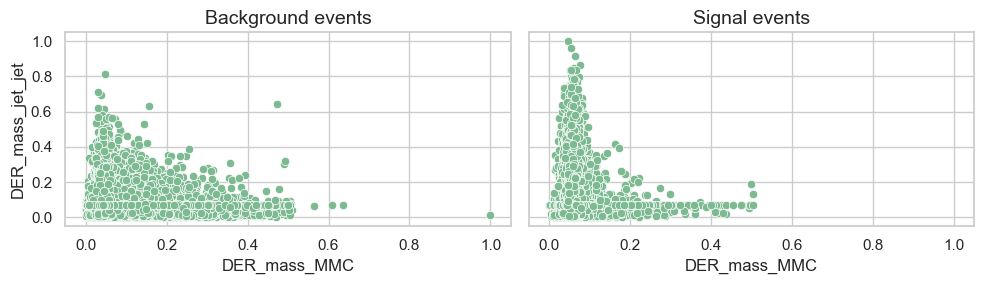

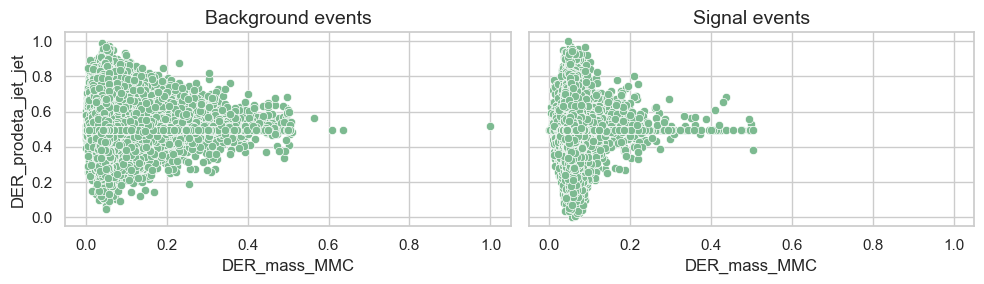

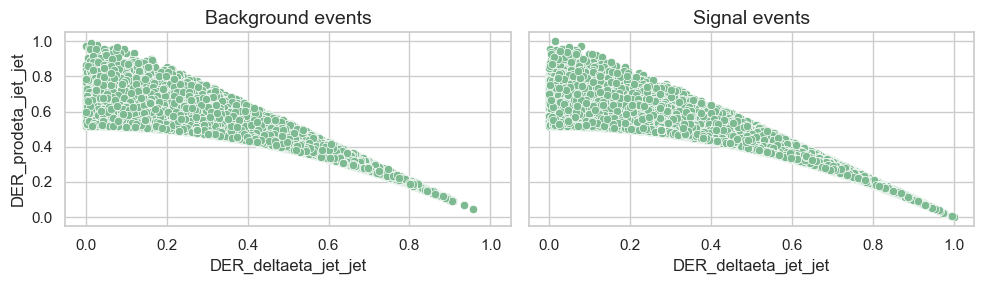

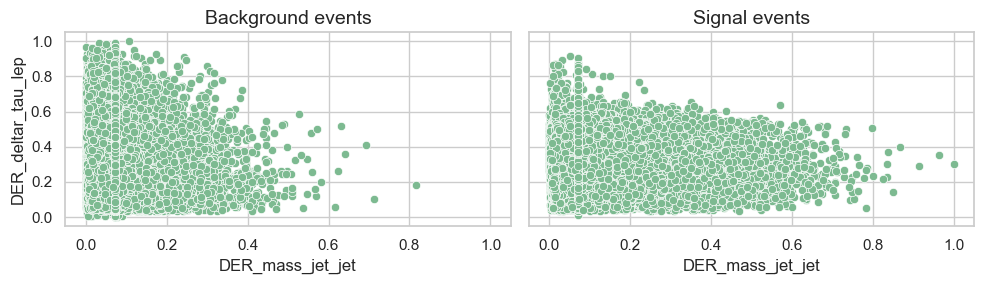

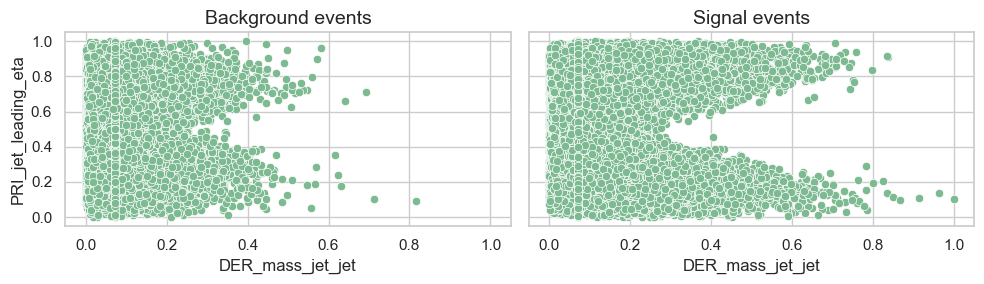

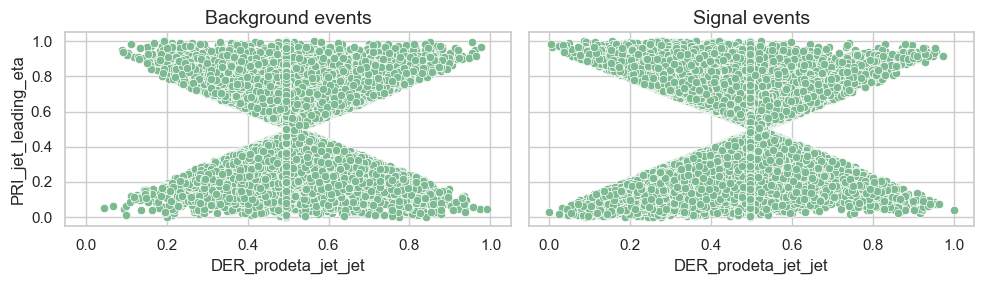

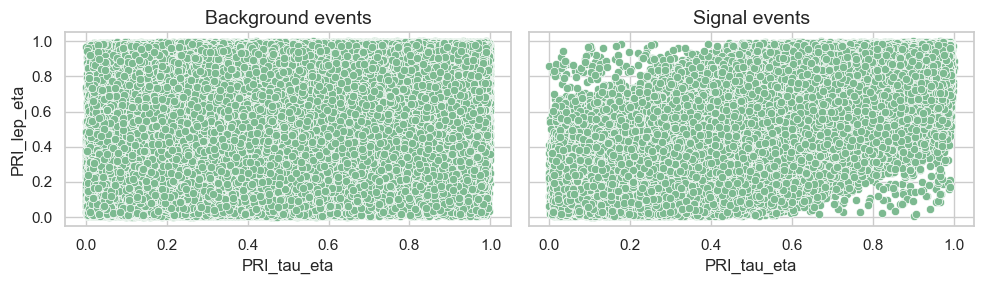

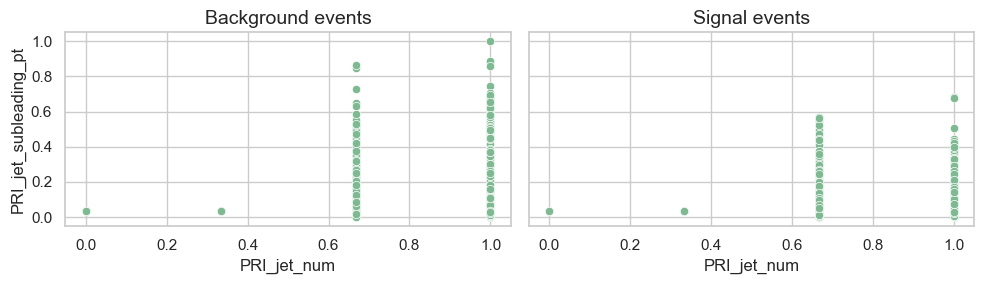

In [11]:

pairs_selected = [
    ('DER_mass_MMC', 'DER_mass_jet_jet'),
    ('DER_mass_MMC', 'DER_prodeta_jet_jet'),
    ('DER_deltaeta_jet_jet', 'DER_prodeta_jet_jet'),
    ('DER_mass_jet_jet', 'DER_deltar_tau_lep'),
    ('DER_mass_jet_jet', 'PRI_jet_leading_eta'),
    ('DER_prodeta_jet_jet', 'PRI_jet_leading_eta'),
    ('PRI_tau_eta', 'PRI_lep_eta'),
    ('PRI_jet_num', 'PRI_jet_subleading_pt')
]

y = data['Label']
X_back = X[y == 0]   # événements background
X_sig  = X[y == 1]   # événements signal


for z in pairs_selected:
    fig, ax = plt.subplots(1, 2, figsize = (10, 3), sharex = True, sharey = True)
    sns.scatterplot(data = X_back, x = z[0], y = z[1], ax = ax[0])
    sns.scatterplot(data = X_sig, x = z[0], y = z[1], ax = ax[1])
    ax[0].set_title("Background events", fontsize = 14)
    ax[1].set_title("Signal events", fontsize = 14)
    plt.tight_layout()

plt.show()

Les représentations émises mettent en évidence des différences de distribution subtiles mais réelles entre les événements de fond et les événements compatibles avec un signal de type Higgs. 

Visuellement, les deux classes se recouvrent très largement, ce qui confirme que l’œil humain et des coupes simples ne suffisent pas pour séparer le signal du bruit. 

Toutefois, certains couples de variables révèlent des motifs caractéristiques : des concentrations plus marquées dans certaines zones, des triangles de densité légèrement déformés, ou des structures asymétriques dans les événements signal par rapport aux événements background. 

**Ces petites différences, imperceptibles dans une analyse univariée, justifient pleinement l’usage de modèles de machine learning capables d’exploiter ces corrélations multivariées complexes pour améliorer la séparation signal/fond et augmenter la sensibilité de la détection du boson de Higgs.**

## II - Unbalance Ratio

Dans le cadre l'application du machine learning, il est essentiel d’évaluer l’équilibre entre les classes signal et background avant d’entraîner un modèle de machine learning.

Les expérimentations du LHC produisent naturellement un nombre d’événements de fond très supérieur au nombre d’événements compatibles avec un signal de type Higgs.

Cette asymétrie statistique, appelée **Unbalance Ratio**, influence directement la difficulté de la tâche de classification : un modèle non adapté risque de privilégier la classe majoritaire et de sous-détecter les événements rares mais physiquement significatifs.

L’analyse de ce ratio permet donc d’anticiper les biais éventuels, de choisir des techniques de rééquilibrage appropriées et d’assurer une évaluation rigoureuse des performances du classifieur dans un contexte où les données sont fortement déséquilibrées.

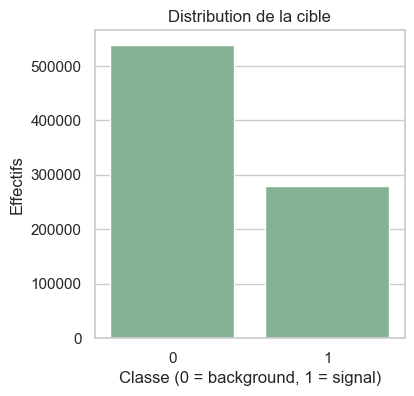

In [12]:
plt.figure(figsize=(4,4))
sns.countplot(x=data['Label'])
plt.title("Distribution de la cible")
plt.xlabel("Classe (0 = background, 1 = signal)")
plt.ylabel("Effectifs")
plt.show()

Pour les besoins de l’exercice, nous commencerons par travailler avec un jeu de données déséquilibré, puis plus tard, avec un jeu de données rééquilibré à l’aide de techniques appropriées. 

Cela nous permettra de mettre en évidence les différences de comportement entre les différents modèles testés et d’évaluer leur capacité de prédiction face à des données présentant un fort déséquilibre, puis en situation équilibrée.

### Découpage en Train and test



In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)

print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(572766, 30) (245472, 30) (572766,) (245472,)


Nous réalisons la séparation du jeu de données en un ensemble d’entraînement et un ensemble de test à l’aide de la fonction `train_test_split`. 

Nous mettons dans l'entrainement 70% des données et dans le test 30 %. 

L’affichage des dimensions obtenues permet de vérifier que la découpe s’est effectuée correctement et que les tailles des ensembles sont conformes aux attentes.

# II - Learning I: Models Only (No additional Paradigms)

En guise de baseline, nous allons évaluer les performances des différents modèles sans appliquer de traitement particulier ni de stratégie spécifique.

In [14]:
#for saving results
list_accuracies=[]
list_F1=[]
list_times=[]
def make_learning_one(model,x_train,y_train,x_test,y_test):
    model_name=str(model).split('(')[0]
    print(f"---------- {model_name} ----------")
    
    clf= model

    deb = time.time()

    clf.fit(x_train, y_train)
    fin=time.time()
    res = clf.predict(x_test)

    list_times.append(fin-deb)
    print(f"temps {model_name} :",round((fin-deb)), "s")

    
    acc=accuracy_score(res,y_test)
    F1=f1_score(res,y_test)
    list_accuracies.append(acc)
    list_F1.append(F1)


    print("accuray : ", round(acc,3))
    print("F1 Score : ", round(F1,3)) # type: ignore
    

    cm = confusion_matrix(y_test, res, labels=clf.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

    fig, ax = plt.subplots(figsize=(7, 4))
    disp.plot(values_format="d", cmap="RdPu", ax=ax)
    plt.tight_layout()
    plt.show()



## 1- Decision Tree

**Le Decision Tree** constitue l’un des modèles supervisés les plus simples et les plus intuitifs.\
Il repose sur une structure arborescente permettant de segmenter l’espace des données en fonction de règles de décision successives optimisées pour séparer les classes. 

Malgré sa simplicité, ce modèle offre une bonne capacité d’interprétation et est un point de départ pertinent pour évaluer les performances de modèles plus avancés dans la détection du signal du boson de Higgs.

---------- DecisionTreeClassifier ----------
temps DecisionTreeClassifier : 22 s
accuray :  0.766
F1 Score :  0.659


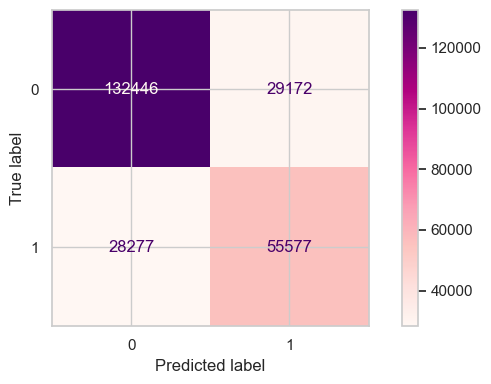

In [15]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

make_learning_one(model,x_train,y_train,x_test,y_test)



## 2- Logistic Regression


**La Logistic Regression** est un modèle linéaire de référence pour les tâches de classification binaire. \
Elle repose sur une fonction logistique permettant d’estimer la probabilité d’appartenance à une classe, ce qui en fait un outil simple, rapide et particulièrement efficace pour établir une première comparaison entre modèles. \
Ce modèle constitue ainsi une baseline solide avant de passer à des algorithmes plus complexes.

Dans `scikit-learn`, le solveur par défaut est liblinear, une méthode adaptée aux jeux de données de petite ou moyenne taille. Pour des volumes plus importants, des solveurs tels que `sag`, fondé sur le gradient moyen stochastique, sont mieux adaptés grâce à leur capacité à optimiser efficacement sur des datasets de grande dimension. 


---------- LogisticRegression ----------
temps LogisticRegression : 3 s
accuray :  0.749
F1 Score :  0.589


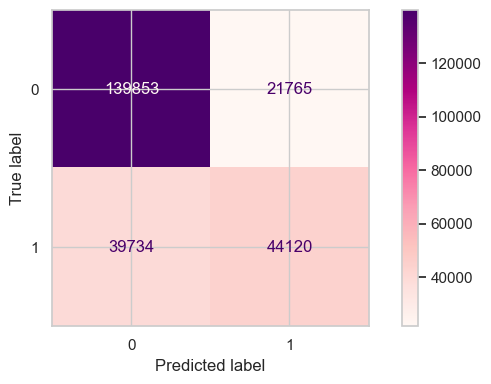

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='sag')

make_learning_one(model,x_train,y_train,x_test,y_test)


##  3- Naive Baysien 

**Le classifieur bayésien** naïf repose sur le théorème de Bayes et sur l’hypothèse d’indépendance conditionnelle entre les variables. \
Bien que cette hypothèse soit souvent simplificatrice dans des contextes réels, ce modèle se révèle particulièrement rapide, léger et efficace sur des données de grande dimension. 

Il constitue ainsi un outil de comparaison pertinent dans notre étude, permettant d’évaluer comment un modèle probabiliste simple se comporte face à la séparation entre signal et background dans la détection du boson de Higgs.

---------- GaussianNB ----------
temps GaussianNB : 0 s
accuray :  0.685
F1 Score :  0.486


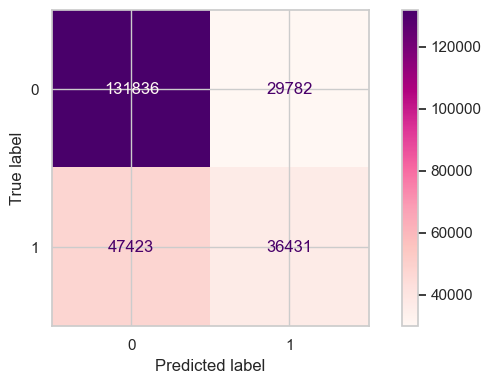

In [17]:
from sklearn.naive_bayes import GaussianNB

model=GaussianNB()

make_learning_one(model,x_train,y_train,x_test,y_test)


## 4- Comparaison

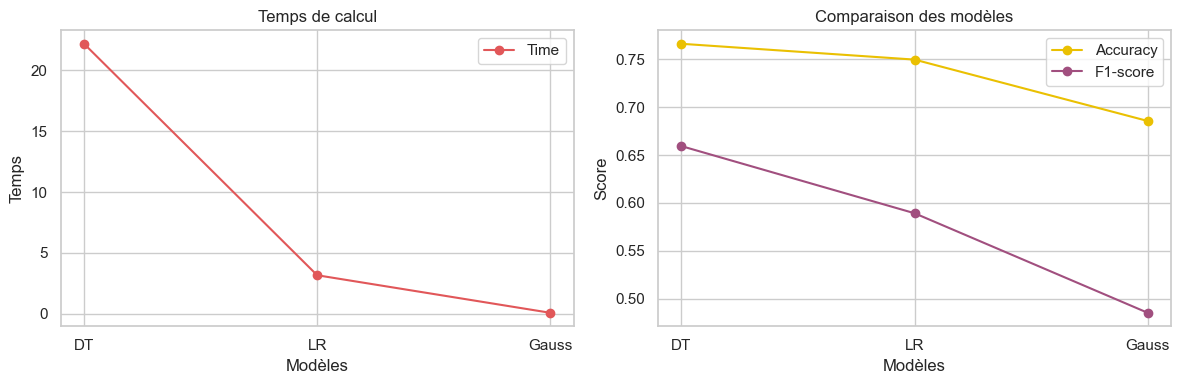

In [18]:
x = ['DT', 'LR', 'Gauss']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Scores
axes[1].plot(x, list_accuracies, marker='o', label='Accuracy', color="#EAC002")
axes[1].plot(x, list_F1, marker='o', label='F1-score', color="#A14F7F")
axes[1].grid(True)
axes[1].set_xlabel("Modèles")
axes[1].set_ylabel("Score")
axes[1].set_title("Comparaison des modèles")
axes[1].legend()


# Temps de calcul
axes[0].plot(x, list_times, marker='o', label='Time', color='#E15759')
axes[0].grid(True)
axes[0].set_xlabel("Modèles")
axes[0].set_ylabel("Temps")
axes[0].set_title("Temps de calcul")
axes[0].legend()


fig.tight_layout()
plt.show()


Les deux graphiques permettent de comparer simultanément les performances et les temps de calcul des modèles évalués. 

En termes de précision (accuracy) et de F1-score, le `Decision Tree` est le modèle le plus performant, confirmant sa capacité à capturer les relations non linéaires présentes dans les données du Higgs.
Toutefois, il s’avère également être le plus coûteux en temps de calcul, ce qui peut devenir un inconvénient lorsque l’on traite des volumes de données beaucoup plus importants.

La `Logistic Regression` représente un compromis intéressant : son temps de calcul est nettement inférieur à celui du `Decision Tree` tout en maintenant des performances acceptables, bien que limitées par son caractère linéaire. 

Le classifieur `Naive Baysian`, quant à lui, se distingue par un temps de calcul quasi nul, mais au prix de performances significativement plus faibles, conséquence directe de l’hypothèse d’indépendance entre variables qui ne correspond pas à la structure réelle des données. 

Ce bilan met en évidence **le trade-off entre performance et coût computationnel**, et souligne l’importance de choisir un modèle adapté à la fois à la complexité des données et aux contraintes de calcul.

# III - Learning II: Ensemble Learning

**L’Ensemble Learning** regroupe une famille de techniques de machine learning qui visent à améliorer les performances d’un modèle en combinant plusieurs apprenants plutôt qu’en s’appuyant sur un seul classifieur.

Cette approche repose sur l’idée qu’un ensemble de modèles, correctement construits et agrégés, peut capturer une plus grande diversité de patterns et réduire les erreurs liées au surapprentissage, au biais ou à la variance. 

Dans le cadre de la détection du boson de Higgs, où les données sont complexes, bruitées et fortement imbriquées, les méthodes d’ensemble offrent un avantage considérable en renforçant la robustesse et la stabilité des prédictions.

Elles permettent ainsi de dépasser les limites observées avec les modèles individuels et constituent une étape naturelle dans la construction de classifieurs plus performants.

## 1- Bagging

**Le Bagging (Bootstrap Aggregating)** est une méthode d’ensemble qui vise à réduire la variance d’un modèle en entraînant plusieurs apprenants indépendants sur des sous-échantillons du jeu de données, générés par tirage aléatoire avec remise (bootstrap).

Les prédictions finales résultent d’une agrégation des modèles individuels, généralement par vote majoritaire ou par moyenne.


### a- Random Forest

**Le Random Forest** représente l’une des implémentations les plus avancées du Bagging. 

Il combine un grand nombre d’arbres de décision entraînés sur des échantillons bootstrap, tout en introduisant une sélection aléatoire de variables à chaque nœud lors de la construction des arbres. 

Cette double source d’aléa permet de réduire encore davantage la corrélation entre les arbres, renforçant ainsi la capacité du modèle à généraliser et à capturer des structures complexes.

Dans le contexte de la détection du boson de Higgs, le Random Forest peut offrir un compromis puissant entre performance, robustesse et interprétabilité, tout en restant relativement peu sensible aux valeurs aberrantes ou au déséquilibre modéré des classes.

---------- RandomForestClassifier ----------
temps RandomForestClassifier : 13 s
accuray :  0.835
F1 Score :  0.744


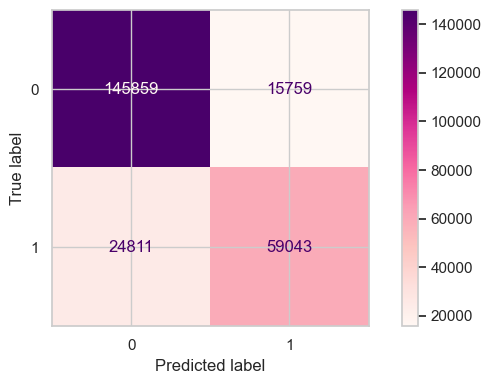

In [19]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier


model= RandomForestClassifier(
    n_estimators=60,
    max_depth=12,
    max_features='sqrt',
    max_samples=0.8,
    n_jobs=-1,
)

make_learning_one(model,x_train,y_train,x_test,y_test)

Ce modèle RandomForestClassifier est configuré pour entraîner une forêt de 60 arbres de décision `(n_estimators=60)`, chacun limité à une profondeur maximale de 12 `(max_depth=12)` afin de contrôler la complexité et réduire le risque de surapprentissage.

Le paramètre `max_features='sqrt'` impose qu’un sous-ensemble aléatoire de variables soit considéré à chaque division, ce qui favorise la diversité entre les arbres et améliore la capacité de généralisation.

De plus, `max_samples=0.8` indique que chaque arbre est entraîné sur 80 % des observations, tirées aléatoirement avec remise, conformément au principe du bootstrap. 

### b- Bagging Classifier with Logistic Regression

Le Bagging Classifier appliqué à une Logistic Regression permet de renforcer la stabilité et la performance d’un modèle linéaire en combinant plusieurs régressions entraînées sur des échantillons bootstrap. 

Dans cette configuration, chaque estimateur est une Logistic Regression classique `(estimator=LogisticRegression(max_iter=1000))`, mais entraînée sur une version légèrement différente du dataset.

Le paramètre `max_samples=1.0` indique que chaque modèle utilise 100 % des observations, tirées avec remise, ce qui assure la diversité entre les estimateurs.

Le choix `max_features=1` force chaque régression à n’utiliser qu’une seule variable aléatoire parmi celles disponibles à chaque entraînement. Cela introduit un niveau d’aléa supplémentaire, analogue au fonctionnement du Random Forest, et permet d’explorer différentes dimensions des données.

Ce paramétrage fait du Bagging un moyen efficace pour compenser la sensibilité de la Logistic Regression au bruit et aux corrélations entre variables, tout en préservant sa rapidité et sa simplicité.

---------- BaggingClassifier ----------
temps BaggingClassifier : 2 s
accuray :  0.658
F1 Score :  0.0


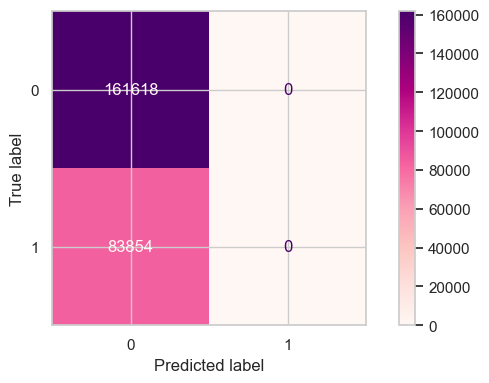

In [ ]:
from sklearn.ensemble import BaggingClassifier

model = BaggingClassifier(
    estimator= LogisticRegression(max_iter=1000),
    max_samples=1,          
    max_features=1,          
    random_state=0,
    n_jobs=-1                 
)

make_learning_one(model,x_train,y_train,x_test,y_test)

### c– Bagging Classifier with Naive Bayes

L’application du Bagging à un classifieur Naïf Bayésien vise à renforcer la robustesse d’un modèle intrinsèquement simple et très rapide.

Le `Naïve Bayes`, fondé sur l’hypothèse d’indépendance conditionnelle entre les variables, peut être sensible aux variations locales des données, en particulier dans des environnements bruités comme ceux issus des collisions du LHC. 

En combinant plusieurs estimateurs via le Bagging, chacun entraîné sur un sous-échantillon bootstrap des données d’origine, on peut atténuer l’impact de cette variabilité.

Dans la configuration actuelle,\
le modèle utilise 50 classifieurs Naïve Bayésien indépendants. Chaque estimateur est entraîné sur 80 % des observations `(max_samples=0.8)`, ce qui accroît la diversité entre les modèles et améliore la capacité d’ensemble à mieux généraliser. L’argument `n_jobs=-1` permet d’exécuter les entraînements en parallèle pour réduire le temps de calcul. 

`GaussianNB(priors=[0.5, 0.5])` fixe les probabilités a priori des classes : 0,5 pour la première classe, 0,5 pour la seconde pour éviter log(0) et des prédictions dégénérées.

Cette stratégie rend le Bagging particulièrement intéressant pour compenser la simplicité du modèle Naïve Bayes tout en conservant sa rapidité.

---------- BaggingClassifier ----------
temps BaggingClassifier : 3 s
accuray :  0.687
F1 Score :  0.505


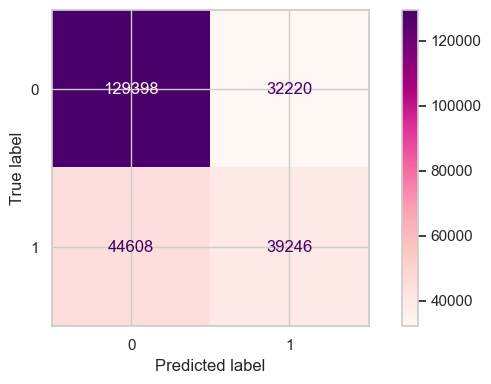

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import BaggingClassifier


model = BaggingClassifier(GaussianNB(priors=[0.5, 0.5]),n_estimators=50,max_samples=0.8,n_jobs=-1)


make_learning_one(model,x_train,y_train,x_test,y_test)

### d- Comparaison

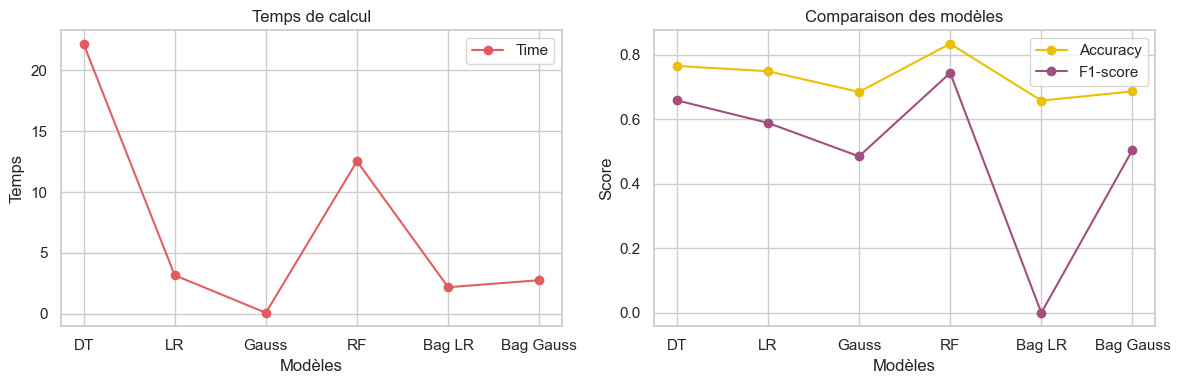

In [22]:
x = ['DT', 'LR', 'Gauss', "RF", "Bag LR", "Bag Gauss"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Scores
axes[1].plot(x, list_accuracies, marker='o', label='Accuracy', color="#EAC002")
axes[1].plot(x, list_F1, marker='o', label='F1-score', color="#A14F7F")
axes[1].grid(True)
axes[1].set_xlabel("Modèles")
axes[1].set_ylabel("Score")
axes[1].set_title("Comparaison des modèles")
axes[1].legend()


# Temps de calcul
axes[0].plot(x, list_times, marker='o', label='Time', color="#E15759F3")
axes[0].grid(True)
axes[0].set_xlabel("Modèles")
axes[0].set_ylabel("Temps")
axes[0].set_title("Temps de calcul")
axes[0].legend()


fig.tight_layout()
plt.show()


Les résultats présentés montrent les performances et les temps de calcul des différents modèles d’ensemble testés en comparaison avec les modèles individuels. 

Le `Random Forest` apparaît nettement comme l’approche la plus performante, atteignant la meilleure accuracy et l’un des meilleurs F1-scores, ce qui confirme l’efficacité de la combinaison d’arbres de décision diversifiés pour capturer la complexité des données du Higgs.

En revanche, ce modèle présente un coût computationnel non négligeable, supérieur à celui de la `Logistic Regression` ou du `Naïve Bayes`, ce qui constitue son principal compromis.

Le Bagging appliqué à la `Logistic Regression` montre ici une forte dégradation du F1-score, qui chute quasiment à zéro. Ce comportement s’explique par l’utilisation de max_features=1, qui contraint chaque sous-modèle à n’utiliser qu’une seule variable : cette perte drastique d’information nuit fortement à la capacité discriminante du modèle final.

Le Bagging appliqué au `Naïve Bayes` présente quant à lui une amélioration modérée de la performance, tout en conservant un temps de calcul très faible, ce qui en fait une solution légère mais moins performante que les modèles à base d’arbres.

Globalement, \
nous notons les méthodes d’ensemble offrent un gain significatif lorsque l’algorithme de base est suffisamment expressif (comme pour les arbres), tandis qu’elles apportent peu — voire dégradent les performances — lorsqu’elles s’appuient sur des modèles trop simples ou trop limités en information.

### e- Exercice 
Faire varier les valeurs du paramètre 'n_estimators' afin de visulaliser l'effet du nombre de modèles dans l'apprentissage d'ensemble sur la qualité du classifieur.

In [23]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, f1_score
import time, matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.naive_bayes")

n_list = [1, 5, 10, 20, 30]
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "GNB": GaussianNB(priors=[0.5, 0.5]),
}

metrics = {name: {"acc": [], "f1": [], "time": []} for name in models}

for n in n_list:
    for name, model in models.items():
        print(f"----------- {name} | n_estimators={n} ----------")
        clf = BaggingClassifier(estimator=model, n_estimators=n, random_state=0, n_jobs=-1)
        t0 = time.time()
        clf.fit(x_train, y_train)
        preds = clf.predict(x_test)
        metrics[name]["time"].append(time.time() - t0)
        metrics[name]["acc"].append(accuracy_score(y_test, preds))
        metrics[name]["f1"].append(f1_score(y_test, preds))



----------- LogReg | n_estimators=1 ----------
----------- GNB | n_estimators=1 ----------
----------- LogReg | n_estimators=5 ----------
----------- GNB | n_estimators=5 ----------


/Users/yerimasika/miniconda3/envs/ML/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


----------- LogReg | n_estimators=10 ----------
----------- GNB | n_estimators=10 ----------
----------- LogReg | n_estimators=20 ----------
----------- GNB | n_estimators=20 ----------
----------- LogReg | n_estimators=30 ----------
----------- GNB | n_estimators=30 ----------


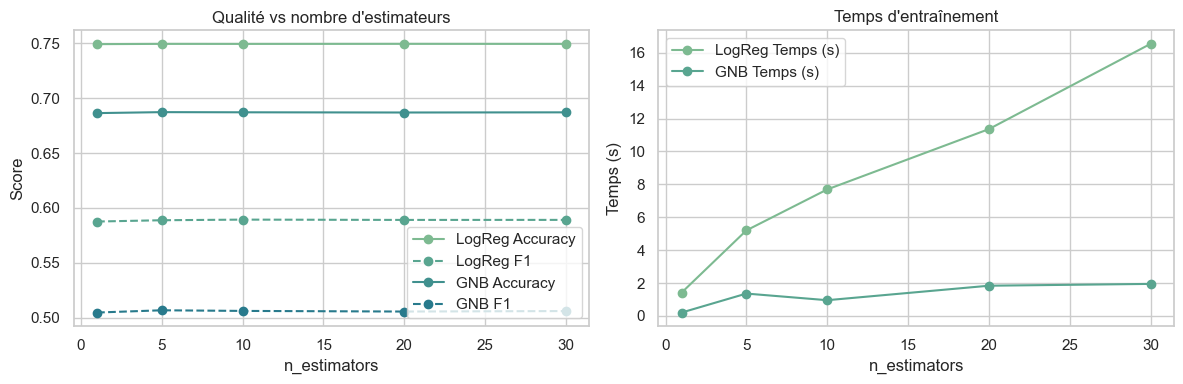

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scores
for name, m in metrics.items():
    axes[0].plot(n_list, m["acc"], marker="o", label=f"{name} Accuracy")
    axes[0].plot(n_list, m["f1"], marker="o", linestyle="--", label=f"{name} F1")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("Score")
axes[0].set_title("Qualité vs nombre d'estimateurs")
axes[0].grid(True)
axes[0].legend()

# Temps
for name, m in metrics.items():
    axes[1].plot(n_list, m["time"], marker="o", label=f"{name} Temps (s)")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Temps (s)")
axes[1].set_title("Temps d'entraînement")
axes[1].grid(True)
axes[1].legend()

fig.tight_layout()
plt.show()


Nous remarquons que la hausse du nombre d'estimateur fais augmenter le temps d'entrainement cependant, les capacités de prédictions restent constantes.

## 2- Boosting

**Le Boosting** est une technique d’ensemble qui vise à améliorer progressivement la performance d’un modèle en entraînant une séquence d’apprenants faibles, chacun cherchant à corriger les erreurs commises par le précédent. 

Contrairement au **Bagging**, qui construit des modèles indépendants pour réduire la variance, le Boosting adopte une approche séquentielle : chaque nouvel estimateur accorde davantage de poids aux observations mal classées, renforçant ainsi sa capacité à traiter les cas difficiles et à réduire le biais global du modèle. 

Cette stratégie en fait un outil particulièrement puissant pour capturer des relations complexes dans des données bruitées et multidimensionnelles, telles que celles issues des collisions du LHC pour la détection du boson de Higgs.

### a- AdaBoost

**AdaBoost** (Adaptive Boosting) est l’un des algorithmes de Boosting les plus connus et les plus utilisés. 

Il repose sur l’idée d’entraîner une succession d’apprenants faibles — souvent des arbres de décision peu profonds — en ajustant à chaque itération les poids associés aux observations. 

Les exemples mal classés lors d’une itération reçoivent un poids plus élevé à la suivante, ce qui oblige les modèles successifs à se concentrer sur les cas les plus difficiles. 

L’agrégation pondérée de l’ensemble de ces estimateurs produit un classifieur final plus performant et généralement moins biaisé que les modèles individuels. 

---------- AdaBoostClassifier ----------
temps AdaBoostClassifier : 46 s
accuray :  0.802
F1 Score :  0.694


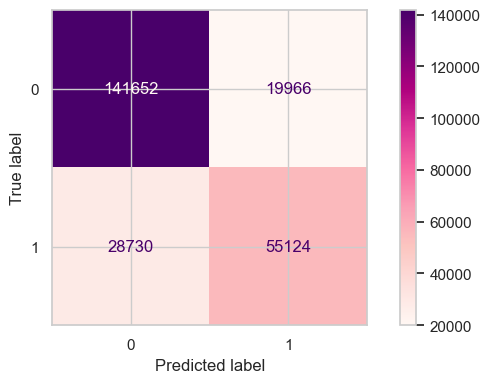

In [25]:
from sklearn.ensemble import AdaBoostClassifier

model=AdaBoostClassifier()

make_learning_one(model,x_train,y_train,x_test,y_test)

### b- Gradient Boost (Gradient Boosted Decision Trees)

Le **Gradient Boosting**, et en particulier les `Gradient Boosted Decision Trees (GBDT)`, constitue une famille de modèles d’ensemble particulièrement performants pour les tâches de classification et de régression. 

Contrairement à `AdaBoost`, qui ajuste principalement les poids des observations, le Gradient Boosting construit chaque nouvel arbre de décision de manière à minimiser directement une fonction de perte via une descente de gradient. 

À chaque itération, un nouvel arbre vient corriger les erreurs résiduelles du modèle précédent, ce qui permet de réduire progressivement le biais et d’améliorer la précision globale. 

Ce cadre algorithmique offre une grande flexibilité, s’adapte naturellement à des données complexes et bruitées, et fournit souvent des performances nettement supérieures aux modèles individuels. 

Dans le contexte de la détection du boson de Higgs, les `GBDT` se révèlent particulièrement pertinant pour capturer des interactions non linéaires et des structures fines entre variables, et améliorer la capacité du modèle à distinguer efficacement le signal du background.

---------- GradientBoostingClassifier ----------
temps GradientBoostingClassifier : 87 s
accuray :  0.815
F1 Score :  0.706


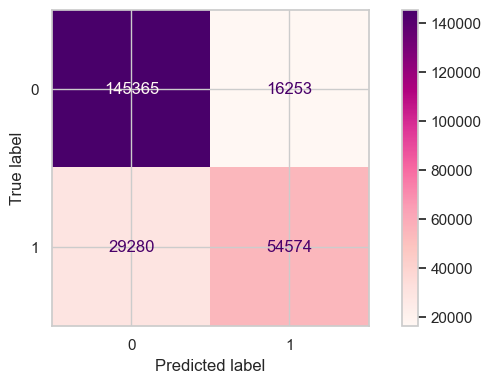

In [26]:
from sklearn.ensemble import GradientBoostingClassifier


model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=2
)


make_learning_one(model,x_train,y_train,x_test,y_test)

### c- comparaison

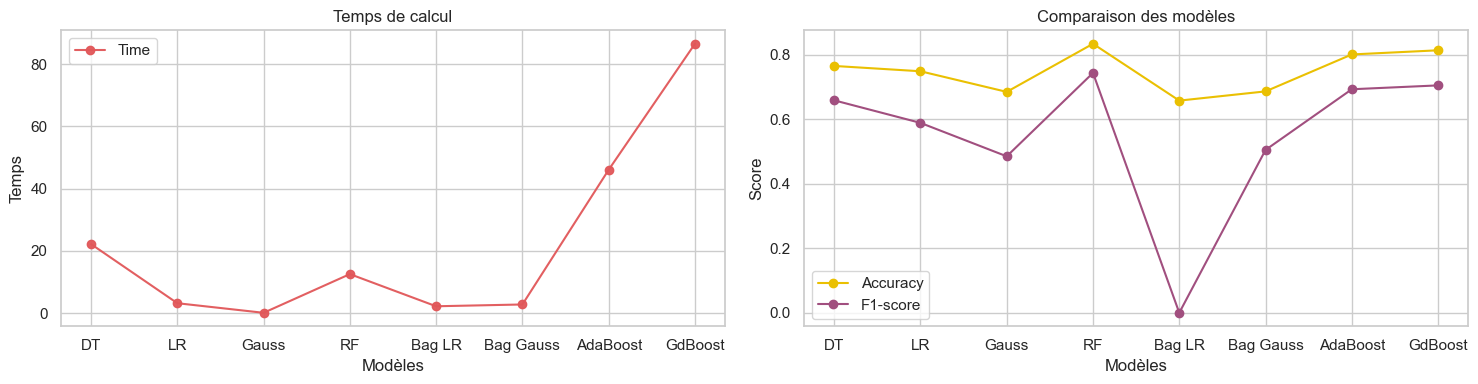

In [27]:
x = ['DT', 'LR', 'Gauss', "RF", "Bag LR", "Bag Gauss", "AdaBoost", "GdBoost" ]

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=False)

# Scores
axes[1].plot(x, list_accuracies, marker='o', label='Accuracy', color="#EAC002")
axes[1].plot(x, list_F1, marker='o', label='F1-score', color="#A14F7F")
axes[1].grid(True)
axes[1].set_xlabel("Modèles")
axes[1].set_ylabel("Score")
axes[1].set_title("Comparaison des modèles")
axes[1].legend()


# Temps de calcul
axes[0].plot(x, list_times, marker='o', label='Time', color="#E15759F3")
axes[0].grid(True)
axes[0].set_xlabel("Modèles")
axes[0].set_ylabel("Temps")
axes[0].set_title("Temps de calcul")
axes[0].legend()


fig.tight_layout()
plt.show()

Les graphiques montrent une comparaison étendue entre les modèles individuels et les différentes méthodes d’ensemble, tant en termes de temps de calcul que de performance. 

Le `Gradient Boosting` se distingue par un temps de calcul particulièrement élevé, nettement supérieur aux autres modèles, mais cette complexité se traduit par des performances solides, avec une accuracy parmi les plus élevées et un F1-score élevé, ce qui confirme sa capacité à capturer des structures fines dans les données du Higgs. 

Le `AdaBoost` affiche également un bon niveau de performance, proche de celui des modèles à base d’arbres, tout en restant plus rapide à entraîner que le Gradient Boosting.

Globalement, cette comparaison met en évidence que les **méthodes d’ensemble basées sur des arbres** (`Random Forest`, `AdaBoost`, `Gradient Boosting`) sont particulièrement adaptées à la détection du boson de Higgs,car elles offrent un rapport performance/coût nettement supérieur aux modèles linéaires ou probabilistes simples.

# V- Learning III : Balance Learning

Afin de traiter le déséquilibre marqué entre les classes signal et background, plusieurs techniques d’échantillonnage seront explorées pour rééquilibrer le jeu de données avant l’entraînement des modèles. 

Ces méthodes permettent soit de réduire la classe majoritaire, soit d’augmenter artificiellement la classe minoritaire, soit de générer de nouveaux exemples synthétiques.

Les approches retenues dans cette étude sont les suivantes :
-	`Under-Sampling` (US) : réduction de la classe majoritaire afin d’obtenir une distribution plus équilibrée.
-	`Over-Sampling` (OS) : duplication ou rééchantillonnage aléatoire de la classe minoritaire.
-	`SMOTE` (Synthetic Minority Over-sampling Technique) : création d’exemples synthétiques en interpolant les observations minoritaires existantes.
-	`BSMOTE` (Borderline-SMOTE) : variante de SMOTE focalisée sur les instances minoritaires situées près de la frontière de décision, là où les modèles commettent le plus d’erreurs.

L’évaluation de ces différentes stratégies permettra d’identifier les techniques les plus efficaces pour améliorer la capacité de détection du boson de Higgs dans un contexte de données fortement déséquilibrées.

In [28]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE

# -------------------------
# UNDER-SAMPLING (rapide)
# -------------------------
print("UNDER-SAMPLING ")
deb = time.time()
us = RandomUnderSampler()
x_us, y_us = us.fit_resample(x_train, y_train) # type: ignore
fin = time.time()
print(f"undersampling time : {round(fin-deb,3)}")
print("UNDER-SAMPLING fini \n")


# -------------------------
# OVER-SAMPLING (rapide)
# -------------------------
print("OVER-SAMPLING ")
deb = time.time()
ros = RandomOverSampler()
x_ros, y_ros = ros.fit_resample(x_train, y_train) # type: ignore
fin = time.time()
print(f"oversampling time : {round(fin-deb,3)}")
print("OVER-SAMPLING fini \n")

# -------------------------
# SMOTE (lent)
# -------------------------
print("SMOTE ")
deb= time.time()
sm = SMOTE()
x_sm, y_sm = sm.fit_resample(x_train, y_train) # type: ignore
fin = time.time()
print(f"smote time : {round(fin-deb,3)}")
print("SMOTE fini \n")


# -------------------------
# Borderline SMOTE (très lent)
# -------------------------
print("Borderline SMOTE ")
deb= time.time()
bl = BorderlineSMOTE()
x_bl, y_bl = bl.fit_resample(x_train, y_train) # type: ignore
fin = time.time()
print(f"boderline smote time : {round(fin-deb,3)}")
print("Borderline SMOTE fini \n")


UNDER-SAMPLING 
undersampling time : 0.069
UNDER-SAMPLING fini 

OVER-SAMPLING 
oversampling time : 0.112
OVER-SAMPLING fini 

SMOTE 
smote time : 13.83
SMOTE fini 

Borderline SMOTE 
boderline smote time : 46.208
Borderline SMOTE fini 



Les temps d’exécution des différentes méthodes d’échantillonnage mettent en évidence des écarts importants en termes de coût computationnel.

Les techniques les plus simples — `undersampling` (0.067 s) et `randomn oversampling` (0.11 s) — sont extrêmement rapides, car elles consistent principalement à supprimer ou dupliquer des observations sans transformation complexe.

En revanche, les méthodes basées sur la génération d’exemples synthétiques présentent des temps beaucoup plus élevés. \
Le `SMOTE` requiert 14.03 secondes, en raison du calcul des plus proches voisins et de l’interpolation entre observations minoritaires.\
Le `Borderline-SMOTE`, qui se concentre sur les instances situées près de la frontière de décision et nécessite des calculs supplémentaires pour identifier ces zones sensibles, est de loin la méthode la plus coûteuse, avec un temps d’exécution de 46.20 secondes. 

**Il est question du compromis classique entre sophistication des méthodes de rééquilibrage et coût computationnel.**

## 1- Decision Tree avec des échantillons balancés

---------- unbalanced -----------
---------- DecisionTreeClassifier ----------
temps DecisionTreeClassifier : 23 s
accuray :  0.766
F1 Score :  0.66


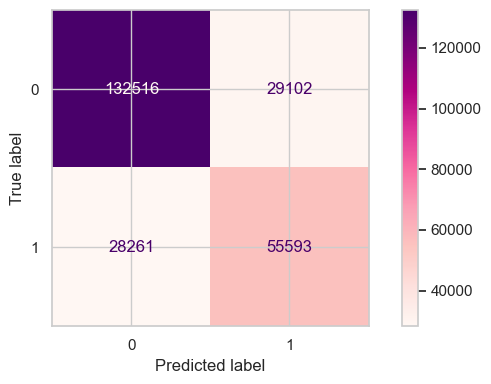

---------- undersampling -----------
---------- DecisionTreeClassifier ----------
temps DecisionTreeClassifier : 15 s
accuray :  0.749
F1 Score :  0.671


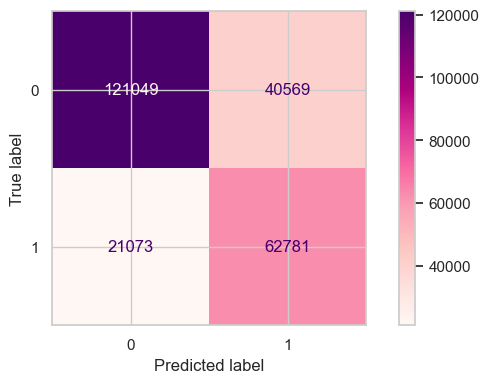

---------- random oversampling -----------
---------- DecisionTreeClassifier ----------
temps DecisionTreeClassifier : 29 s
accuray :  0.765
F1 Score :  0.657


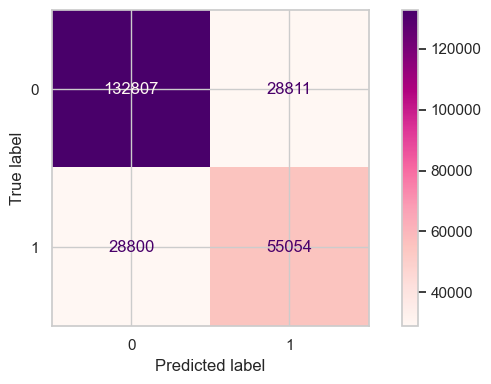

---------- smote -----------
---------- DecisionTreeClassifier ----------
temps DecisionTreeClassifier : 35 s
accuray :  0.76
F1 Score :  0.671


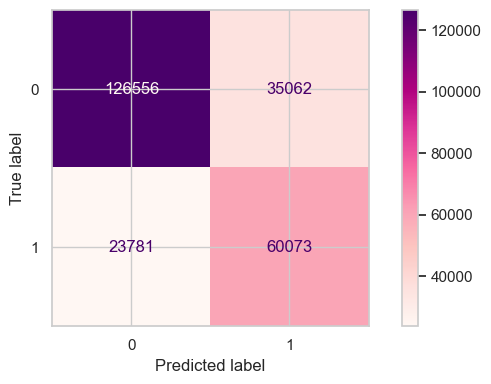

--------- borderline smote -----------
---------- DecisionTreeClassifier ----------
temps DecisionTreeClassifier : 36 s
accuray :  0.754
F1 Score :  0.666


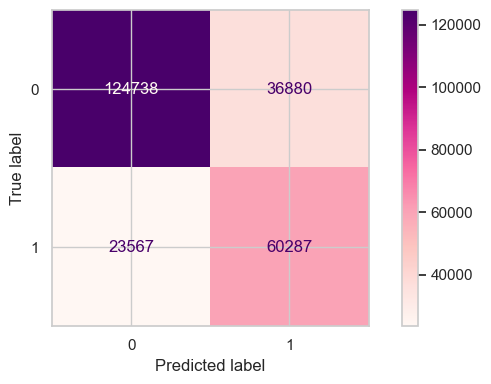

In [29]:
from sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier()

print("---------- unbalanced -----------")
make_learning_one(model,x_train,y_train,x_test,y_test)


print("---------- undersampling -----------")
make_learning_one(model,x_us,y_us,x_test,y_test)

print("---------- random oversampling -----------")
make_learning_one(model,x_ros,y_ros,x_test,y_test)

print("---------- smote -----------")
make_learning_one(model,x_sm,y_sm,x_test,y_test)

print("--------- borderline smote -----------")
make_learning_one(model,x_bl,y_bl,x_test,y_test)

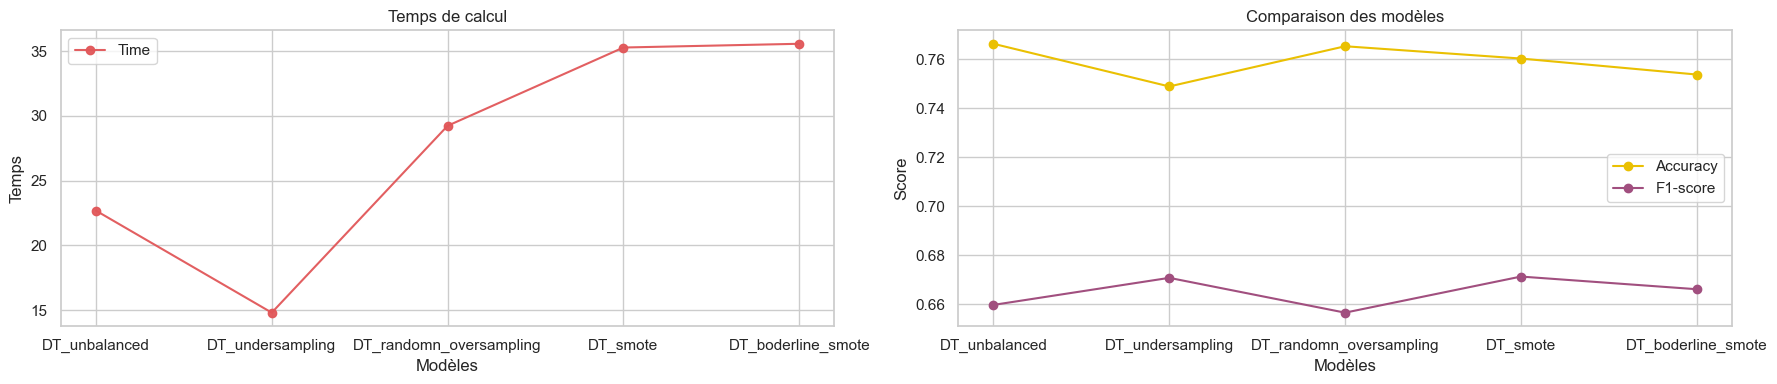

In [30]:
x = ['DT_unbalanced','DT_undersampling', 'DT_randomn_oversampling', 'DT_smote' ,'DT_boderline_smote']

fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharex=False)

# Scores
axes[1].plot(x, list_accuracies[-5:], marker='o', label='Accuracy', color="#EAC002")
axes[1].plot(x, list_F1[-5:], marker='o', label='F1-score', color="#A14F7F")
axes[1].grid(True)
axes[1].set_xlabel("Modèles")
axes[1].set_ylabel("Score")
axes[1].set_title("Comparaison des modèles")
axes[1].legend()


# Temps de calcul
axes[0].plot(x, list_times[-5:], marker='o', label='Time', color="#E15759F3")
axes[0].grid(True)
axes[0].set_xlabel("Modèles")
axes[0].set_ylabel("Temps")
axes[0].set_title("Temps de calcul")
axes[0].legend()


fig.tight_layout()
plt.show()

On observe d’abord que le modèle sans rééquilibrage présente un temps de calcul intermédiaire, supérieur à celui obtenu avec l’undersampling mais inférieur aux méthodes d’oversampling. Les techniques basées sur la génération d’exemples synthétiques, en particulier `SMOTE` et `Borderline-SMOTE`, restent les plus coûteuses, car elles augmentent artificiellement la taille du jeu de données.

Du point de vue des performances,
le `Decision Tree` entraîné sur les données déséquilibrées affiche une accuracy élevée, comparable — voire légèrement supérieure — à celles obtenues après rééquilibrage. 
Toutefois, son F1-score demeure inférieur, ce qui reflète la difficulté du modèle à détecter correctement la classe minoritaire dans un contexte où le signal est sous-représenté. 

L’`undersampling` améliore légèrement le F1-score mais au prix d’une baisse de l’accuracy, conséquence directe de la suppression d’une partie de la classe majoritaire.

Les méthodes `SMOTE` et `Borderline-SMOTE` offrent un compromis intéressant. \
Elles améliorent la détection du signal (F1-score) sans détériorer significativement l’accuracy, tout en conservant l’intégralité de l’information d’origine.

**Ces résultats confirment que, dans le cadre de la détection du boson de Higgs, les méthodes d’oversampling sont globalement préférables au simple undersampling, car elles permettent d’améliorer la capacité de classification tout en préservant les données rares et essentielles à l’identification du signal.**

## 2- Classification avec Baysian Naif sur des données balancées

---------- unbalanced -------------
---------- GaussianNB ----------
temps GaussianNB : 0 s
accuray :  0.685
F1 Score :  0.486


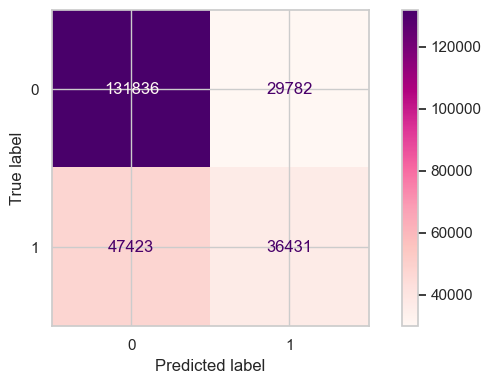

---------- undersampling -----------
---------- GaussianNB ----------
temps GaussianNB : 0 s
accuray :  0.687
F1 Score :  0.505


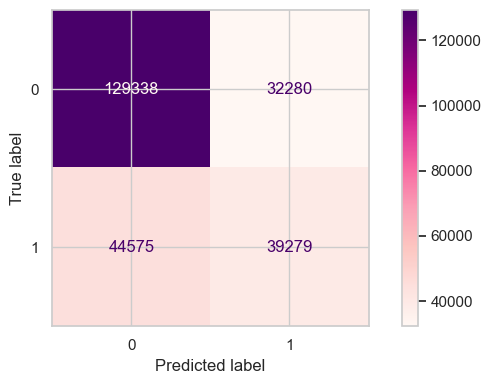

--------- random oversampling -----------
---------- GaussianNB ----------
temps GaussianNB : 0 s
accuray :  0.686
F1 Score :  0.503


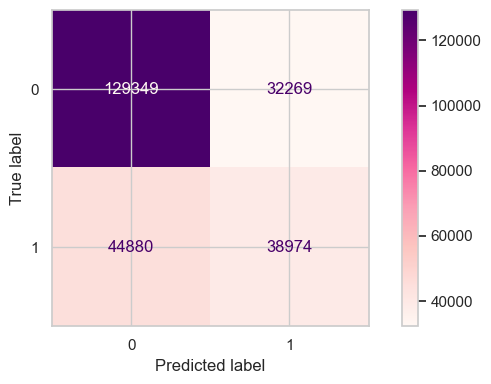

---------- smote -----------
---------- GaussianNB ----------
temps GaussianNB : 0 s
accuray :  0.698
F1 Score :  0.532


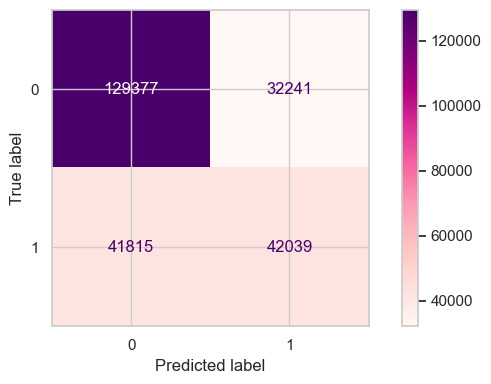

---------- borderline smote -----------
---------- GaussianNB ----------
temps GaussianNB : 0 s
accuray :  0.702
F1 Score :  0.567


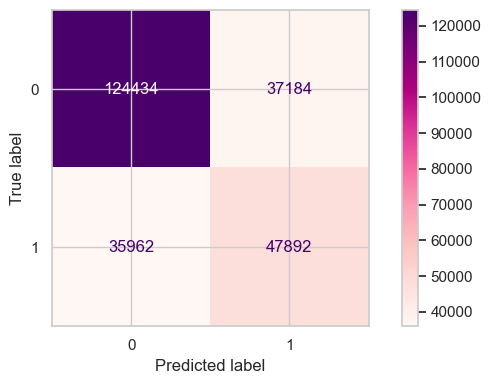

In [31]:
from sklearn.naive_bayes import GaussianNB

model= GaussianNB()

print("---------- unbalanced -------------")
make_learning_one(model,x_train,y_train,x_test,y_test)


print("---------- undersampling -----------")
make_learning_one(model,x_us,y_us,x_test,y_test)

print("--------- random oversampling -----------")
make_learning_one(model,x_ros,y_ros,x_test,y_test)

print("---------- smote -----------")
make_learning_one(model,x_sm,y_sm,x_test,y_test)

print("---------- borderline smote -----------")
make_learning_one(model,x_bl,y_bl,x_test,y_test)

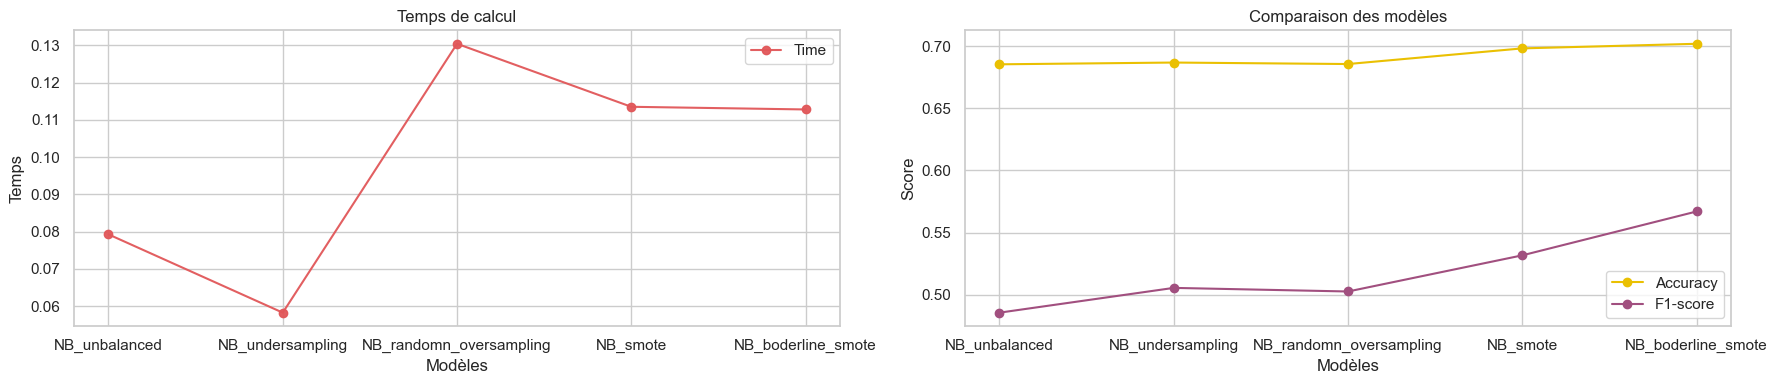

In [32]:
x = ['NB_unbalanced','NB_undersampling', 'NB_randomn_oversampling', 'NB_smote' ,'NB_boderline_smote']

fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharex=False)

# Scores
axes[1].plot(x, list_accuracies[-5:], marker='o', label='Accuracy', color="#EAC002")
axes[1].plot(x, list_F1[-5:], marker='o', label='F1-score', color="#A14F7F")
axes[1].grid(True)
axes[1].set_xlabel("Modèles")
axes[1].set_ylabel("Score")
axes[1].set_title("Comparaison des modèles")
axes[1].legend()


# Temps de calcul
axes[0].plot(x, list_times[-5:], marker='o', label='Time', color="#E15759F3")
axes[0].grid(True)
axes[0].set_xlabel("Modèles")
axes[0].set_ylabel("Temps")
axes[0].set_title("Temps de calcul")
axes[0].legend()


fig.tight_layout()
plt.show()

Comme attendu, le temps d’exécution reste extrêmement faible pour l’ensemble des variantes, ce qui constitue l’un des principaux avantages de ce modèle. 

Les méthodes d’oversampling ,en particulier le `randomn oversampling` et `SMOTE`, entraînent une légère augmentation du temps de calcul, liée à la génération d’échantillons supplémentaires, mais cette hausse demeure marginale.

En termes de performance, on observe que le `Naïve Bayes` est relativement peu sensible à l’accuracy, qui reste quasi constante pour toutes les méthodes testées. 

En revanche, le F1-score, plus représentatif de la capacité à identifier correctement la classe minoritaire, montre une progression notable lorsque des techniques d’oversampling sont utilisées. 

Le modèle initial (NB_unbalanced) présente un F1-score très faible, reflétant la difficulté du `Naïve Bayes` à gérer le déséquilibre des classes. \
L’undersampling apporte donc une légère amélioration, mais ce sont surtout `SMOTE` et `Borderline-SMOTE` qui permettent une hausse significative du F1-score, preuve que la génération d’exemples synthétiques aide le modèle à mieux distinguer le signal du bruit.



# VI Cost-Sensitive Learning

**Le Cost-Sensitive Learning** consiste à intégrer explicitement les coûts associés aux différentes erreurs de classification dans l’entraînement d’un modèle. 

Dans un contexte comme la détection du boson de Higgs, les erreurs n’ont pas toutes la même importance : manquer un événement de signal (faux négatif) est généralement bien plus problématique que de classer à tort un événement de background comme signal (faux positif). 

Les approches classiques, qui supposent des coûts d’erreur identiques pour toutes les classes, ne sont donc pas toujours adaptées aux situations où l’une des classes est rare mais critique. 

Le Cost-Sensitive Learning permet de corriger ce biais en assignant des pénalités plus élevées aux erreurs les plus coûteuses, améliorant ainsi la sensibilité du modèle à la classe minoritaire sans nécessiter de rééquilibrage explicite du dataset. 

Cette section explore les principales méthodes permettant d’intégrer ces coûts dans la classification et leur impact sur la détection d’événements rares.

## 1- Pondération des classes (class_weight) dans les modeles

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import time
import matplotlib.pyplot as plt

models_cs = {
    "LR_cs": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "LR": LogisticRegression(max_iter=1000),

    "DT_cs": DecisionTreeClassifier(max_depth=12, class_weight="balanced"),
    "DT": DecisionTreeClassifier(max_depth=12),

    "RF_cs": RandomForestClassifier(
        n_estimators=60, max_depth=12, max_features='sqrt', max_samples=0.8,
        class_weight="balanced", n_jobs=-1
    ),
    "RF": RandomForestClassifier(
        n_estimators=60, max_depth=12, max_features='sqrt', max_samples=0.8,
        n_jobs=-1
    )
}

metrics = {name: {"acc": None, "f1": None, "time": None} for name in models_cs}

for name, model in models_cs.items():
    print(f"----------- {name} ----------")
    t0 = time.time()
    model.fit(x_train, y_train)
    metrics[name]["time"] = time.time() - t0 # type: ignore
    preds = model.predict(x_test)
    metrics[name]["acc"] = accuracy_score(y_test, preds) # type: ignore
    metrics[name]["f1"] = f1_score(y_test, preds) # type: ignore



----------- LR_cs ----------
----------- LR ----------
----------- DT_cs ----------
----------- DT ----------
----------- RF_cs ----------
----------- RF ----------


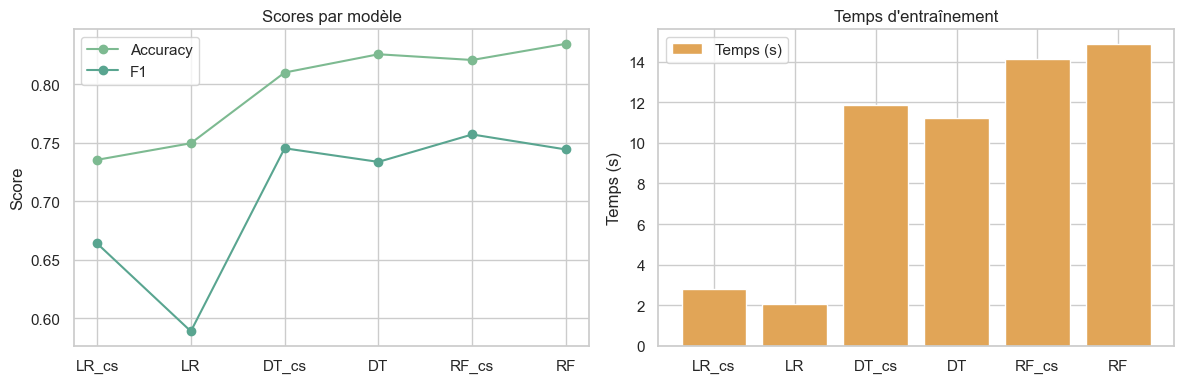

In [34]:
# Préparation pour le plot
labels = list(metrics.keys())
acc_vals = [metrics[k]["acc"] for k in labels]
f1_vals = [metrics[k]["f1"] for k in labels]
time_vals = [metrics[k]["time"] for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scores
axes[0].plot(labels, acc_vals, marker="o", label="Accuracy")
axes[0].plot(labels, f1_vals, marker="o", label="F1")
axes[0].set_ylabel("Score")
axes[0].set_title("Scores par modèle")
axes[0].grid(True, axis="y")
axes[0].legend()

# Temps
axes[1].bar(labels, time_vals, color="#E1A557", label="Temps (s)")
axes[1].set_ylabel("Temps (s)")
axes[1].set_title("Temps d'entraînement")
axes[1].grid(True, axis="y")
axes[1].legend()

fig.tight_layout()
plt.show()


Les résultats obtenus mettent en évidence l’impact du Cost-Sensitive Learning sur les performances et le temps d’entraînement des modèles. 

Du point de vue des scores, l’ajout d’une pondération de classes améliore globalement la capacité des modèles à détecter la classe minoritaire. 
Cela est particulièrement visible pour la `Logistic Regression`, dont le F1-score passe de 0.59 à environ 0.66 lorsque le modèle est entraîné avec `class_weight="balanced"`. 

De même, le `Decision Tree` bénéficie clairement de cette approche : le modèle cost-sensitive (DT_cs) atteint un F1-score supérieur à celui du modèle standard, illustrant une meilleure prise en compte du signal rare.

Le `Random Forest` reste le modèle le plus performant, mais avec une amélioration plus modérée sous version cost-sensitive (RF_cs). 
Cela s’explique par le fait que les forêts d’arbres sont naturellement plus robustes au déséquilibre des classes, ce qui limite l’impact du réajustement des poids. 


En termes de temps de calcul, l’introduction de `class_weight` augmente légèrement le coût d’entraînement pour les modèles d’arbres, car chaque split doit intégrer les poids des classes dans le calcul des impuretés. Néanmoins, cette hausse reste modérée et ne compromet pas la faisabilité computationnelle.

Globalement, \
ces résultats montrent que le `Cost-Sensitive Learning par pondération des classes` améliore la sensibilité au signal, particulièrement pour les modèles linéaires et les arbres simples, tout en maintenant un coût de calcul raisonnable. Cette approche apparaît donc comme une alternative pertinente aux méthodes d’échantillonnage lorsque l’on souhaite améliorer la détection d’événements rares sans modifier la distribution du dataset.

## 2- Pondération des observations (sample_weight)

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score
import time

sw = compute_sample_weight(class_weight="balanced", y=y_train)

models = {
    "DT_sw": DecisionTreeClassifier(max_depth=12),
    "LR_sw": LogisticRegression(max_iter=1000),
    "RF_sw": RandomForestClassifier(n_estimators=60, max_depth=12, n_jobs=-1),
}

metrics_sw = {name: {"acc": None, "f1": None, "time": None} for name in models}

for name, model in models.items():
    print(f"----------- {name} ----------")
    t0 = time.time()
    model.fit(x_train, y_train, sample_weight=sw)
    metrics_sw[name]["time"] = time.time() - t0 # type: ignore
    preds = model.predict(x_test)
    metrics_sw[name]["acc"] = accuracy_score(y_test, preds) # type: ignore
    metrics_sw[name]["f1"] = f1_score(y_test, preds) # type: ignore




----------- DT_sw ----------
----------- LR_sw ----------
----------- RF_sw ----------


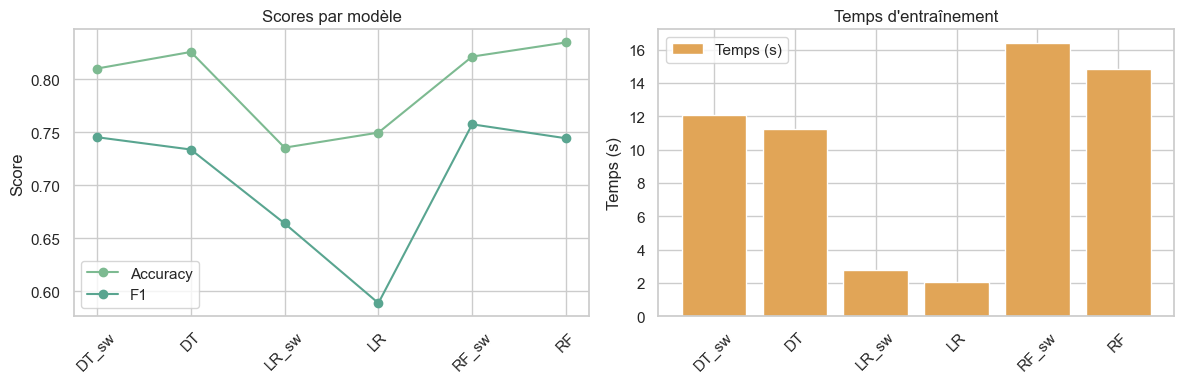

In [36]:
# Préparation pour le plot
labels_sw = list(metrics_sw.keys())
acc_vals_sw = [metrics_sw[k]["acc"] for k in labels_sw]
f1_vals_sw  = [metrics_sw[k]["f1"] for k in labels_sw]
time_vals_sw = [metrics_sw[k]["time"] for k in labels_sw]

labels = list(metrics.keys())
acc_vals = [metrics[k]["acc"] for k in labels]
f1_vals  = [metrics[k]["f1"] for k in labels]
time_vals = [metrics[k]["time"] for k in labels]

# Ordre souhaité : DT_sw, LR_sw, RF_sw, puis DT, LR, RF
order = ["DT_sw","DT", "LR_sw","LR", "RF_sw", "RF"]

all_labels = order
all_acc_vals = [metrics_sw.get(k, metrics.get(k))["acc"] for k in order] # type: ignore
all_f1_vals  = [metrics_sw.get(k, metrics.get(k))["f1"] for k in order] # type: ignore
all_time_vals = [metrics_sw.get(k, metrics.get(k))["time"] for k in order] # type: ignore

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scores
axes[0].plot(all_labels, all_acc_vals, marker="o", label="Accuracy")
axes[0].plot(all_labels, all_f1_vals, marker="o", linestyle="-", label="F1")
axes[0].set_ylabel("Score")
axes[0].set_title("Scores par modèle")
axes[0].grid(True, axis="y")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Temps
axes[1].bar(all_labels, all_time_vals, color="#E1A557", label="Temps (s)")
axes[1].set_ylabel("Temps (s)")
axes[1].set_title("Temps d'entraînement")
axes[1].grid(True, axis="y")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()


Pour le `Decision Tree`, l’utilisation de `sample_weight` améliore légèrement le F1-score (DT_sw), signe que le modèle détecte mieux la classe minoritaire lorsqu’on augmente artificiellement l’importance des observations de signal. Cependant, cette amélioration reste modérée car l’arbre est déjà sensible aux déséquilibres et aux variations locales des données.

Pour la `Logistic Regression`, la pondération a un effet inverse : la version cost-sensitive (LR_sw) présente un F1-score inférieur à celui du modèle standard. \
Cette dégradation s’explique par le fait que la régression logistique, modèle linéaire, est moins flexible et peut être déstabilisée par des pondérations fortes lorsque les classes sont fortement imbriquées dans l’espace des features.

En revanche, le `Random Forest` montre une nette amélioration avec la pondération des observations : le modèle RF_sw obtient des scores particulièrement élevés en accuracy comme en F1-score, dépassant légèrement la version standard. Cela confirme que les ensembles d’arbres profitent de la prise en compte explicite des coûts, en particulier dans la détection des événements rares comme le signal du boson de Higgs.

Concernant les temps d’entraînement,\
la pondération entraîne une légère augmentation pour les modèles fondés sur des arbres (DT_sw et RF_sw), liée à la prise en compte des poids dans l’évaluation des splits mais l’impact reste faible pour la `Logistic Regression`.

Globalement, \
ces résultats montrent que le **sample-weighting** est particulièrement efficace pour les modèles ensemblistes, alors qu’il peut être moins bénéfique — voire contre-productif — pour les modèles linéaires. \
Cette approche constitue donc une solution flexible et performante pour renforcer la sensibilité au signal, sans modifier la distribution du dataset.

## 3- Changement du seuil de décision avec le Youden Point

Dans les modèles de classification binaire, la prédiction finale est généralement obtenue en appliquant un seuil fixe de 0.5 sur la probabilité estimée. 

Toutefois, ce seuil standard n’est pas optimal lorsque les classes sont déséquilibrées ou lorsque le coût d’une erreur diffère selon la classe, comme dans la détection du boson de Higgs, où manquer un événement de signal (faux négatif) est plus grave que détecter par erreur un background (faux positif). 

Le threshold moving consiste à ajuster ce seuil pour améliorer la sensibilité du modèle à la classe minoritaire.

Une manière rigoureuse de déterminer ce seuil optimal consiste à utiliser le Youden Point, défini comme le point maximisant l’indice de Youden :
``J = Sensibilité + Spécificité - 1``

Ce point correspond au seuil qui offre simultanément la meilleure combinaison de sensibilité et de spécificité. 
Il permet de choisir un seuil adapté au contexte, sans hypothèses supplémentaires ni rééquilibrage des données, tout en renforçant la capacité du modèle à détecter les cas rares.

Dans le cadre de la détection du Higgs, cette approche augmente généralement le recall du signal, réduisant les faux négatifs, au prix d’une légère hausse des faux positifs. 

Elle offre donc une alternative intéressante aux méthodes d’échantillonnage ou de pondération en ajustant directement la règle de décision du modèle, sans modifier son entraînement.

---
*Sensibilité = La sensibilité mesure la capacité d’un modèle à détecter correctement les événements positifs, c’est-à-dire les signaux dans ton étude.\
*Spécificité = La spécificité mesure la capacité d’un modèle à reconnaître correctement les événements négatifs, c’est-à-dire les backgrounds dans ton étude.

In [37]:
import numpy as np
from sklearn.metrics import roc_curve, accuracy_score, f1_score

# 1. Probabilités prédites pour la classe positive (signal)

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score
import time

sw = compute_sample_weight(class_weight="balanced", y=y_train)

models = {
    "DT_new_seuil": DecisionTreeClassifier(max_depth=12),
    "LR_new_seuil": LogisticRegression(max_iter=1000),
    "RF_new_seuil": RandomForestClassifier(n_estimators=60, max_depth=12, n_jobs=-1),
}

metrics_new = {name: {"acc": None, "f1": None, "time": None} for name in models}

for name, model in models.items():
    print(f"----------- {name} ----------")
    t0 = time.time()
    model.fit(x_train, y_train, sample_weight=sw)
    metrics_new[name]["time"] = time.time() - t0 # type: ignore
    y_proba = model.predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    youden_index = tpr - fpr
    best_threshold = thresholds[np.argmax(youden_index)]
    print("Seuil optimal (Youden):", round(best_threshold,4))
    preds = (y_proba >= best_threshold).astype(int)
    metrics_new[name]["acc"] = accuracy_score(y_test, preds) # type: ignore
    metrics_new[name]["f1"] = f1_score(y_test, preds) # type: ignore



----------- DT_new_seuil ----------
Seuil optimal (Youden): 0.5062
----------- LR_new_seuil ----------
Seuil optimal (Youden): 0.4665
----------- RF_new_seuil ----------
Seuil optimal (Youden): 0.4954


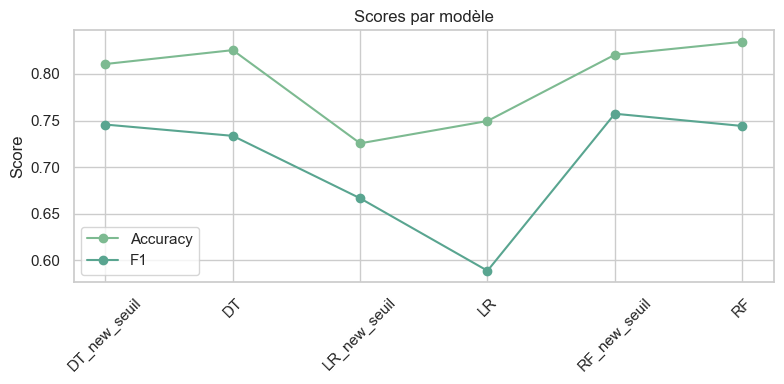

In [38]:
# Préparation pour le plot
labels_sw = list(metrics_new.keys())
acc_vals_sw = [metrics_new[k]["acc"] for k in labels_sw]
f1_vals_sw  = [metrics_new[k]["f1"] for k in labels_sw]
time_vals_sw = [metrics_new[k]["time"] for k in labels_sw]

labels = list(metrics.keys())
acc_vals = [metrics[k]["acc"] for k in labels]
f1_vals  = [metrics[k]["f1"] for k in labels]
time_vals = [metrics[k]["time"] for k in labels]


order = ["DT_new_seuil", "DT", "LR_new_seuil", "LR", "RF_new_seuil", "RF"]

def get(metric_dict, k, key):
    return metric_dict[k][key] if k in metric_dict else None

all_acc_vals  = [get(metrics_new, k, "acc")  if k in metrics_new else get(metrics, k, "acc")  for k in order]
all_f1_vals   = [get(metrics_new, k, "f1")   if k in metrics_new else get(metrics, k, "f1")   for k in order]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(order, all_acc_vals, marker="o", label="Accuracy") # type: ignore
ax.plot(order, all_f1_vals, marker="o", linestyle="-", label="F1") # type: ignore
ax.set_ylabel("Score")
ax.set_title("Scores par modèle")
ax.grid(True, axis="y")
ax.legend()
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()


Ce graphique compare, pour chaque modèle, les performances obtenues avec le seuil par défaut (0,5) et avec le seuil optimisé par l’indice de Youden (DT_new_seuil, LR_new_seuil, RF_new_seuil). 

On observe que le changement de seuil modifie principalement le F1-score, qui augmente pour les versions new_seuil, signe d’une meilleure prise en compte de la classe minoritaire (signal), tandis que l’accuracy reste globalement stable ou diminue légèrement. 

Cela traduit le compromis attendu : en abaissant le seuil de décision, le modèle détecte davantage d’événements de signal (moins de faux négatifs), au prix d’un peu plus de faux positifs, ce qui est cohérent avec l’objectif de physique. 

Le temps d’entraînement est identique entre les versions classiques et new_seuil, ce qui est logique puisque le seuil n’intervient qu’en phase de décision et ne modifie pas l’optimisation du modèle lui-même. \
Ainsi, l’ajustement du seuil par le Youden Point apparaît comme une méthode peu coûteuse mais efficace pour améliorer la sensibilité au boson de Higgs sans réentraîner ni complexifier les modèles.

# VII- Comparaison et interprétation des résultats

L’ensemble des expérimentations menées — modèles individuels, méthodes d’ensemble, techniques de rééquilibrage des données et approches de cost-sensitive learning — permet d’obtenir une vision complète de la performance des différents algorithmes appliqués à la détection du boson de Higgs. 

Dans cette section, nous analysons de manière comparative les résultats obtenus afin de dégager les tendances principales, d’identifier les modèles les plus efficaces et d’évaluer l’impact des différentes stratégies de traitement du déséquilibre et des coûts d’erreur. 

Cette interprétation synthétique vise à comprendre non seulement quels modèles atteignent les meilleures performances, mais également pourquoi certaines méthodes se révèlent plus adaptées que d’autres à la structure particulière des données issues des collisions du LHC.

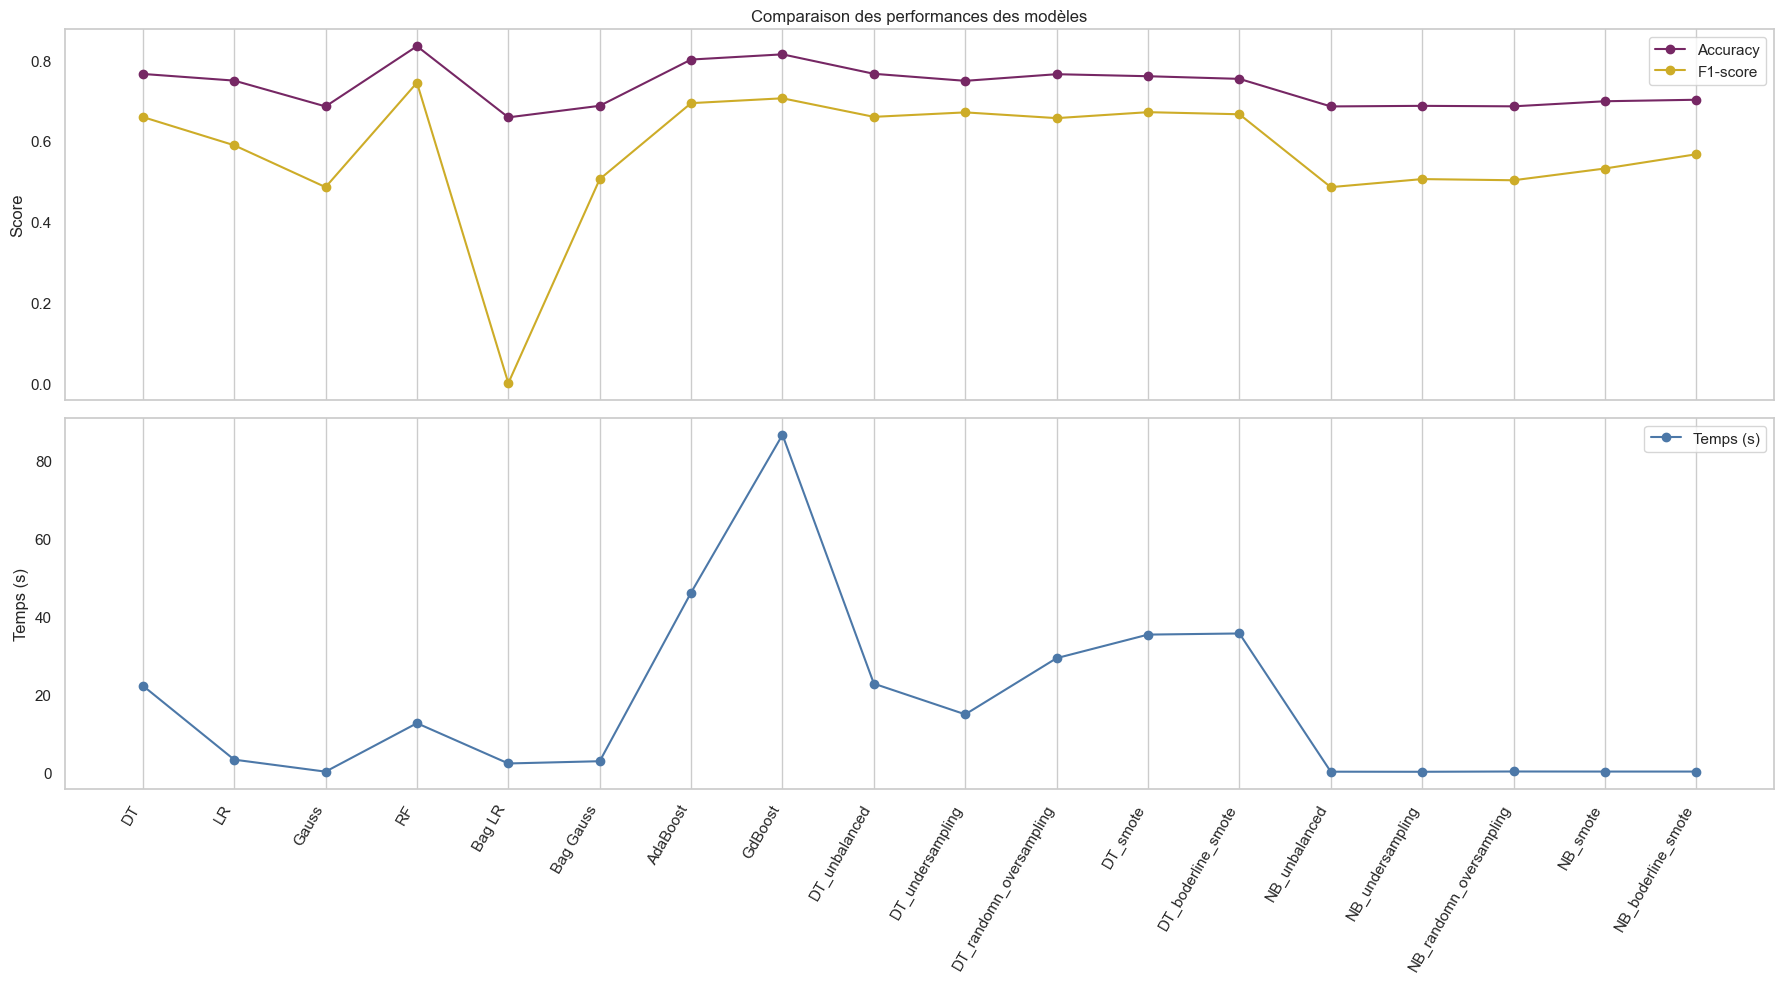

In [39]:
import matplotlib.pyplot as plt

first_x = ['DT','LR','Gauss','RF','Bag LR','Bag Gauss','AdaBoost','GdBoost',
           'DT_unbalanced','DT_undersampling','DT_randomn_oversampling','DT_smote',
           'DT_boderline_smote','NB_unbalanced','NB_undersampling',
           'NB_randomn_oversampling','NB_smote','NB_boderline_smote']

xpos = range(len(first_x))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Scores
ax1.plot(xpos, list_accuracies, marker="o", color="#762764", label="Accuracy")
ax1.plot(xpos, list_F1, marker="o", linestyle="-", color="#CDAC28", label="F1-score")
ax1.set_ylabel("Score")
ax1.set_title("Comparaison des performances des modèles")
ax1.grid(axis="y")
ax1.legend()

# Temps
ax2.plot(xpos, list_times, marker="o", linestyle="-", color="#4C78A8", label="Temps (s)")
ax2.set_ylabel("Temps (s)")
ax2.set_xticks(xpos)
ax2.set_xticklabels(first_x, rotation=60, ha="right")
ax2.grid(axis="y")
ax2.legend()

fig.tight_layout()
plt.show()


Ce graphique fournit une vue d’ensemble de l’ensemble des modèles évalués, intégrant à la fois leurs performances (accuracy et F1-score) et leur coût de calcul. \
Plusieurs tendances générales se dégagent nettement. 

Les modèles d’ensemble basés sur des arbres — notamment `Random Forest`, `AdaBoost` et `Gradient Boosting` — se situent parmi les plus performants, avec des F1-scores élevés et une bonne stabilité de l’accuracy. \
Leur coût de calcul varie toutefois considérablement : ``AdaBoost`` reste modéré, tandis que `Gradient Boosting` est de loin le plus coûteux en temps d’entraînement, ce qui constitue son principal inconvénient malgré ses bonnes performances.

À l’inverse, les méthodes basées sur un `classifieur Naïve Bayes` affichent un temps de calcul quasi nul, confirmant leur extrême rapidité.\
L’amélioration apportée par les techniques d’oversampling (`SMOTE` et `Borderline-SMOTE`) est réelle pour le F1-score, mais les performances demeurent globalement inférieures à celles des modèles plus complexes. 

Les résultats montrent également que l’`undersampling`, tout en étant très rapide, réduit souvent l’accuracy, car il élimine une partie importante de la classe majoritaire.

Les techniques d’ensemble combinant `Bagging` et `Logistic Regression` présentent des performances nettement plus faibles que les autres modèles, en particulier avec un F1-score très bas. \
Ces résultats s’expliquent par la structure même du modèle, qui se retrouve fortement limité par l’utilisation d’un nombre restreint de variables par estimateur. 

Enfin, les arbres de décision classiques conservent un profil équilibré : leur temps d’entraînement est raisonnable et leurs performances restent solides, légèrement améliorées par certaines techniques d’échantillonnage ou de pondération.

Globalement, \
Aucune méthode ne domine sur l’ensemble des critères, cependant **les modèles d’ensemble à base d’arbres** constituent le meilleur compromis entre performance prédictive et robustesse sur les données complexes et déséquilibrées de la recherche du boson de Higgs.

# Conclusion


L’ensemble des expérimentations réalisées dans ce travail met en évidence la complexité et l’exigence de la détection du boson de Higgs à partir de données issues des collisions du LHC. \
Les données présentent plusieurs défis majeurs : **un déséquilibre important entre les classes, une variabilité élevée, ainsi que des relations non linéaires difficiles à capturer pour des modèles standards.**

Afin de répondre à ces contraintes, de multiples approches ont été étudiées : **modèles de base, méthodes d’ensemble, stratégies de rééquilibrage des données et techniques de cost-sensitive learning**, permettant d’obtenir une vue d’ensemble complète et comparative des différentes solutions possibles.

Les résultats montrent clairement que **les `modèles d’ensemble` basés sur les arbres, comme `Random Forest`, `AdaBoost` et `Gradient Boosting`**, offrent les meilleures performances en termes de précision et de capacité à identifier correctement les événements de signal. \
Leur aptitude à capturer des interactions complexes et à gérer le bruit inhérent aux données en fait des candidats particulièrement adaptés à ce type de problème. 

**Les techniques de rééquilibrage**, en particulier `SMOTE` et `Borderline-SMOTE`, améliorent sensiblement la détection de la classe minoritaire pour les modèles sensibles au déséquilibre, tandis que le cost-sensitive learning — via `class_weight`, `sample_weight` ou le `réglage du seuil de décision` — constitue une alternative efficace lorsque l’on souhaite renforcer la sensibilité sans modifier la distribution des données.

Enfin, \
cette étude met en lumière le compromis indispensable entre performance prédictive, coût computationnel et capacité d’interprétation. 
**Alors que les modèles simples sont rapides mais limités, les approches plus sophistiquées atteignent des performances élevées au prix d’un temps d’entraînement plus important.**

Ainsi, \
**la combinaison de méthodes d’ensemble, de rééquilibrage adapté et d’une prise en compte explicite des coûts d’erreur** apparaît comme la stratégie la plus efficace pour traiter des données complexes et déséquilibrées telles que celles de la recherche du boson de Higgs.

